## Trabajo final de Análisis de datos: Recorridos en Ecobici

Integrantes:
- Alejandro García Peña
- Juan Francisco Nadal
- Elian Ricardo Pinzas

Docentes:
- Esp. Lic. María Carina Roldán
- Esp. Ing. Ariadna Garmendia

Carrera de Especialización en Inteligencia Artificial  
Laboratorio de Sistemas Embebidos  
Facultad de Ingeniería de la Universidad de Buenos Aires  

### Introducción

- Para este trabajo práctico se eligió el set de datos __"Recorridos en Ecobici"__.
- __Ecobici__ o __“BA Ecobici”__ es un sistema de bicicletas compartidas que funciona en la Ciudad de Buenos Aires.
-  Comenzó a funcionar en 2010 con un total de 3 estaciones y 72 bicicletas.
- En la actualidad posee más de 380 estaciones y 3600 bicicletas con presencia en 47 de los 48 barrios porteños.
- Se realizan más de 200,000 viajes por mes
- Forma de uso: el sistema requiere que el usuario se registre y pague un pase. Una vez computado el pago, se permite disponer de la bicicleta por una determinada cantidad de tiempo. Al finalizar su uso, la bicicleta debe dejarse en un punto de anclaje dentro de alguna de las estaciones habilitadas.
- El servicio se encuentra actualmente concesionado a Tembici (empresa brasileña) desde 2019 y por 10 años.


### Introducción: set de datos

Dentro del repositorio de la Ciudad de Buenos Aires (https://data.buenosaires.gob.ar/dataset/bicicletas-publicas) pueden encontrarse distintos sets de datos correspondientes a distintos años.
- El año elegido para desarrollar el presente TP es 2024. Dicho archivo es _badata_ecobici_recorridos_realizados_2024.zip_ (161 MB). Para cada registro allí contenido se describe un viaje registrado desde una estación inicial hasta una estación destino indicando, adicionalmente, otros parámetros del viaje (por ejemplo: tiempo insumido, datos de la estación de origen y destino, coordenadas de las estaciones, sexo del usuario, etc)
- Adicionalmente en el repositorio puede encontrarse otro archivo correspondiente al año 2024: _usuarios_ecobici_2024.xls_. Ese set de datos indica los usuarios que se dieron de alta durante ese año.

A los fines del presente TP, el archivo de alta de usuarios será ignorado. El desarrollo se centrará en el archivo de recorridos (_badata_ecobici_recorridos_realizados_2024.zip_.)

## Exploración y comprensión de los datos

### - Cargar el dataset proporcionado y realizar un análisis exploratorio de los datos.

In [52]:
import geopandas as gpd
import pandas as pd
import math
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from shapely.geometry import Point
import statsmodels.stats.stattools as sms

from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
ecobici_df = pd.read_csv("./dataset/badata_ecobici_recorridos_realizados_2024.zip")

### - Describir las características principales del dataset, incluyendo el número de observaciones, número de variables y tipos de datos.

In [3]:
ecobici_df.head()

,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero
0,20428222,568,2024-01-23 18:36:00,513,308 - SAN MARTIN II,Av. San Martín 5129,-58.490739,-34.597130,2024-01-23 18:45:28,498,055 - HABANA,Gral. José Gervasio Artigas 4298 (y Habana),-58.494959,-34.586598,992557.0,FIT,MALE
1,20431744,1355,2024-01-23 22:41:20,460,133 - BEIRO Y SEGUROLA,Segurola 3194,-58.511930,-34.607500,2024-01-23 23:03:55,382,204 - Biarritz,Biarritz 2403,-58.477255,-34.605431,320782.0,FIT,FEMALE
2,20429936,0,2024-01-23 20:06:22,467,328 - SARMIENTO II,Sarmiento 2037,-58.395893,-34.605514,2024-01-23 20:06:22,6,006 - Parque Lezama,"Avenida Martin Garcia, 295",-58.369758,-34.628526,828678.0,FIT,FEMALE
3,20429976,0,2024-01-23 20:08:17,382,204 - Biarritz,Biarritz 2403,-58.477255,-34.605431,2024-01-23 20:08:17,460,133 - BEIRO Y SEGUROLA,Segurola 3194,-58.511930,-34.607500,320782.0,ICONIC,FEMALE
4,20424802,680,2024-01-23 15:18:39,137,137 - AZOPARDO Y CHILE,AZOPARDO 700,-58.367492,-34.615598,2024-01-23 15:29:59,150,150 - RODRIGO BUENO,Av. España 2200,-58.355465,-34.618755,861425.0,FIT,FEMALE


El set de datos posee 3.559.284 entradas y 17 columnas:

| Nombre | Descripción | Tipo |
|-|-|-|
|id_recorrido                   | Número identificador de recorrido                    | Categórica nominal     |
| duracion_recorrido            | Duración del recorrido                               | Numérica               |
| fecha_origen_recorrido        | Fecha en que inició el recorrido                     | Categórica / Numérica  |
| id_estacion_origen            | Número identificador de estación de origen           | Categórica nominal     |
| nombre_estacion_origen        | Nombre de estación de origen                         | Categórica nominal     |
| direccion_estacion_origen     | Dirección de estación de origen                      | Categórica nominal     |
| long_estacion_origen          | Longitud de estación de origen                       | Numérica               |
| lat_estacion_origen           | Latitud de estación de origen                        | Numérica               |
| fecha_destino_recorrido       | Fecha en que finalizó el recorrido                   | Categórica / Numérica  |
| id_estacion_destino           | Número identificador de estación de destino          | Categórica nominal     |
| nombre_estacion_destino       | Nombre de estación de destino                        | Categórica nominal     |
| direccion_estacion_destino    | Dirección de estación de destino                     | Categórica nominal     |
| long_estacion_destino         | Longitud (coordenada) de estación de destino         | Numérica               |
| lat_estacion_destino          | Latitud (coordenada) de estación de destino          | Numérica               |
| id_usuario                    | Número identificador de usuario                      | Categórica nominal     |
| modelo_bicicleta              | Nombre del modelo de la bicicleta usada en recorrido | Categórica nominal     |
| genero                        | Género del usuario del recorrido                     | Categórica binaria     |

Ajuste de variables

In [4]:
df_ecobici_numericas = ['duracion_recorrido', 'long_estacion_origen', 'lat_estacion_origen', 'long_estacion_destino', 'lat_estacion_destino']
df_ecobici_categoricas = ['id_recorrido', 'fecha_origen_recorrido', 'id_estacion_origen', 'nombre_estacion_origen', 'direccion_estacion_origen', 'fecha_destino_recorrido', 'id_estacion_destino', 'nombre_estacion_destino', 'direccion_estacion_destino', 'id_usuario', 'modelo_bicicleta', 'genero']

# Mapping para numericas y para categoricas
dtype_map = {col: 'float64'  for col in df_ecobici_numericas}
dtype_map.update({col: 'category' for col in df_ecobici_categoricas}) 

# Se aplica el mapping al dataframe
ecobici_df = ecobici_df.astype(dtype_map)

ecobici_df.dtypes

id_recorrido                  category
duracion_recorrido             float64
fecha_origen_recorrido        category
id_estacion_origen            category
nombre_estacion_origen        category
direccion_estacion_origen     category
long_estacion_origen           float64
lat_estacion_origen            float64
fecha_destino_recorrido       category
id_estacion_destino           category
nombre_estacion_destino       category
direccion_estacion_destino    category
long_estacion_destino          float64
lat_estacion_destino           float64
id_usuario                    category
modelo_bicicleta              category
genero                        category
dtype: object

#### **Variable duracion_recorrido**

Se inicia el análisis a partir de la variable: __duracion_recorrido__, que indica cuanto dura cada recorrido.  
La primera transformación a realizar para que el análisis sea más simple será convertir la columna de segundos a minutos. Esto evitará las cuentas mentales de dividir por todo el tiempo por 60 para tratar de dimensionar en segundos algo que naturalmente se piensa en minutos

In [5]:
ecobici_df['duracion_recorrido'] = ecobici_df['duracion_recorrido'] / 60

In [6]:
# Codigo tomado de clase_02_intro_EDA_Titanic
def cuartiles(variable):
    Q1 = variable.quantile(0.25)
    Q2 = variable.quantile(0.50)  # Percentile 5-0 - Equivalente a la mediana
    Q3 = variable.quantile(0.75)
    return Q1, Q2, Q3

In [7]:
def aclaracion_tiempo(minutos_en_flotante: float) -> str:
    minutos_fraccionarios, minutos = math.modf(minutos_en_flotante)
    return f"({int(minutos)} minutos {int(minutos_fraccionarios * 60)} segundos)"

In [8]:
print("Duración de recorridos:")

print(f"Media: {ecobici_df['duracion_recorrido'].mean()}, {aclaracion_tiempo(ecobici_df['duracion_recorrido'].mean())}")
print(f"Mediana: {ecobici_df['duracion_recorrido'].median()}, {aclaracion_tiempo(ecobici_df['duracion_recorrido'].median())}")
for i, moda in enumerate(ecobici_df['duracion_recorrido'].mode(), 1):
    tiempo_legible = aclaracion_tiempo(moda)
    print(f"Moda {i}: {moda} {tiempo_legible}")

# Estadística robusta
duracion_recorrido_Q1, duracion_recorrido_Q2, duracion_recorrido_Q3 = cuartiles(ecobici_df['duracion_recorrido'])

print()
print("Estadística robusta:")
print("Q1 (25%):", duracion_recorrido_Q1, aclaracion_tiempo(duracion_recorrido_Q1))
print("Q2 (Mediana, 50%):", duracion_recorrido_Q2, aclaracion_tiempo(duracion_recorrido_Q2))
print("Q3 (75%):", duracion_recorrido_Q3, aclaracion_tiempo(duracion_recorrido_Q3))

# Límites teóricos para detectar outliers
duracion_recorrido_IQR = duracion_recorrido_Q3 - duracion_recorrido_Q1
limite_inferior_para_outliers = duracion_recorrido_Q1 - 1.5 * duracion_recorrido_IQR
limite_superior_para_outliers = duracion_recorrido_Q3 + 1.5 * duracion_recorrido_IQR

print()
print("Límite inferior para detectar outliers: ", limite_inferior_para_outliers)
print("Límite superior para detectar outliers: ", limite_superior_para_outliers)

print("Rango intercuartil: ", duracion_recorrido_IQR, aclaracion_tiempo(duracion_recorrido_IQR))

print()
print(f"Asímetría de la variable 'duracion_recorrido': {ecobici_df['duracion_recorrido'].skew():.4f}")
print(f"Curtosis de la variable 'duracion_recorrido': {ecobici_df['duracion_recorrido'].kurtosis():.4f}")

Duración de recorridos:
Media: 21.247112794783085, (21 minutos 14 segundos)
Mediana: 14.683333333333334, (14 minutos 41 segundos)
Moda 1: 0.03333333333333333 (0 minutos 2 segundos)

Estadística robusta:
Q1 (25%): 8.216666666666667 (8 minutos 13 segundos)
Q2 (Mediana, 50%): 14.683333333333334 (14 minutos 41 segundos)
Q3 (75%): 24.566666666666666 (24 minutos 33 segundos)

Límite inferior para detectar outliers:  -16.308333333333337
Límite superior para detectar outliers:  49.09166666666667
Rango intercuartil:  16.35 (16 minutos 21 segundos)

Asímetría de la variable 'duracion_recorrido': 156.2195
Curtosis de la variable 'duracion_recorrido': 30108.1573


Se trata entonces de una distribución de recorridos altamente asimétrica confirmado por el cálculo de asimetría (skewness) y los valores de Moda < Mediana < Media.

In [9]:
def plot_histograma(dataframe: pd.DataFrame, ax, parametro, titulo, bins=100, range_vals=(0, 100)):
    ax.hist(dataframe[parametro], bins=bins, range=range_vals, color='lightblue', edgecolor='black')

    ax.axvline(dataframe[parametro].mode()[0], color='purple', ls='--', lw=2, label='Moda')
    ax.axvline(dataframe[parametro].mean(), color='red', ls='--', lw=2, label='Media')
    ax.axvline(dataframe[parametro].median(), color='green', ls='--', lw=2, label='Mediana')
    ax.legend()
    ax.set_title(titulo)

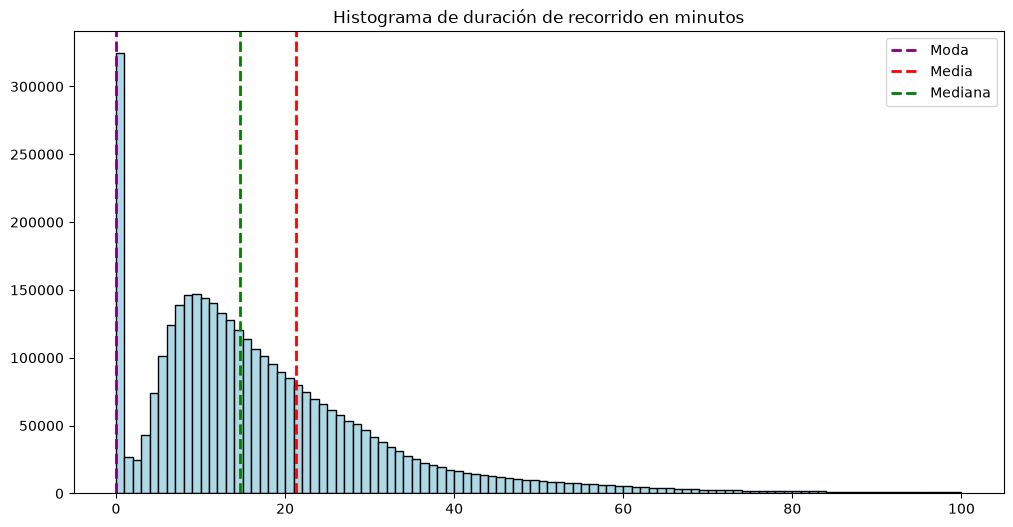

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

plot_histograma(dataframe=ecobici_df, ax=ax, parametro='duracion_recorrido', titulo="Histograma de duración de recorrido en minutos")

plt.show()

Adicionalmente, se muestra la distribución de porcentajes de registros de viajes entre distintos intervalos por tiempo

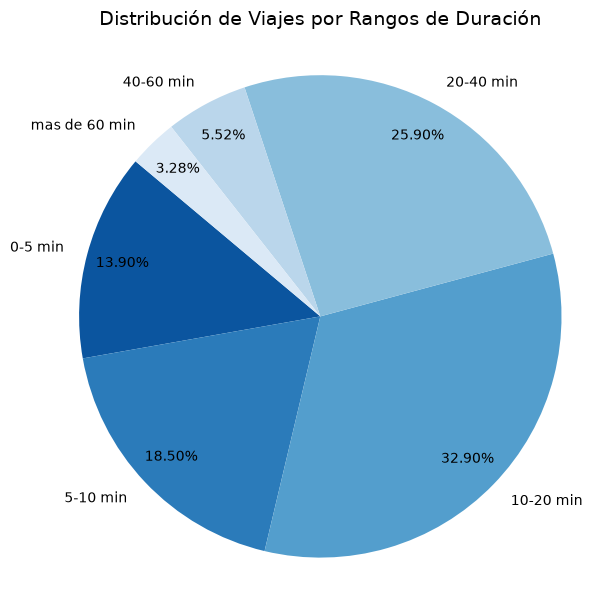

In [11]:
# Se definen intervalos en minutos
cortes = [0, 5, 10, 20, 40, 60, float('inf')]
etiquetas = ['0-5 min', '5-10 min', '10-20 min', '20-40 min', '40-60 min', 'mas de 60 min']

intervalos = pd.cut(ecobici_df['duracion_recorrido'], bins=cortes, labels=etiquetas, include_lowest=True)
conteo_absoluto = intervalos.value_counts().sort_index()

plt.figure(figsize=(6, 6))

colores = sns.color_palette('Blues_r', len(etiquetas)) 

plt.pie(
    conteo_absoluto,
    labels=conteo_absoluto.index,
    autopct='%1.2f%%',
    startangle=140,
    colors=colores,
    pctdistance=0.85, # Aleja un poco los porcentajes del centro para que no se encimen
    textprops={'fontsize': 10}
)

plt.title('Distribución de Viajes por Rangos de Duración', fontsize=14, pad=20)
plt.axis('equal')  
plt.tight_layout()
plt.show()

##### **Tratamiento de outliers para variable duracion_recorrido**

#### Ajuste superior e inferior de duraciones

Tratándose de una distribución altamente asimétrica, se utiliza la fórmula ajustada con parámetros exponenciales de Hubert y Vandervieren _(Hubert, M. & Vandervieren, E., 2008. "An adjusted boxplot for skewed distributions," Computational Statistics & Data Analysis, Elsevier, vol. 52(12), pages 5186-5201, August.)_

Se calcula entonces el valor de medcouple

In [12]:
duraciones_de_recorridos = ecobici_df['duracion_recorrido'].dropna()

total = 0

muestra_duraciones = duraciones_de_recorridos.sample(n=10000, random_state=42).values    
mc_estimado = sms.medcouple(muestra_duraciones)

print(f"El medcouple (MC) estimado de los datos es: {mc_estimado:.4f}")

El medcouple (MC) estimado de los datos es: 0.2357


Dado que $MC > 0$ los límites ajustados ($L_I$ y $L_S$) se calculan como:
$$L_I = Q_1 - 1.5 \cdot e^{-4 \cdot MC} \cdot IQR$$
$$L_S = Q_3 + 1.5 \cdot e^{3 \cdot MC} \cdot IQR$$

In [13]:
# Fórmula con corrección exponencial
limite_inferior_con_correccion_exponencial = duracion_recorrido_Q1 - 1.5 * math.exp(-4 * mc_estimado) * duracion_recorrido_IQR
limite_superior_con_correccion_exponencial = duracion_recorrido_Q3 + 1.5 * math.exp(3 * mc_estimado) * duracion_recorrido_IQR

print(f"Límite inferior con corrección: {limite_inferior_con_correccion_exponencial:.3f}")
print(f"Límite superior con corrección: {limite_superior_con_correccion_exponencial:.4f}")

Límite inferior con corrección: -1.338
Límite superior con corrección: 74.3012


Dado que el límite inferior es un valor muy pequeño se decide considerar solamente valores entre 3 y 74 minutos

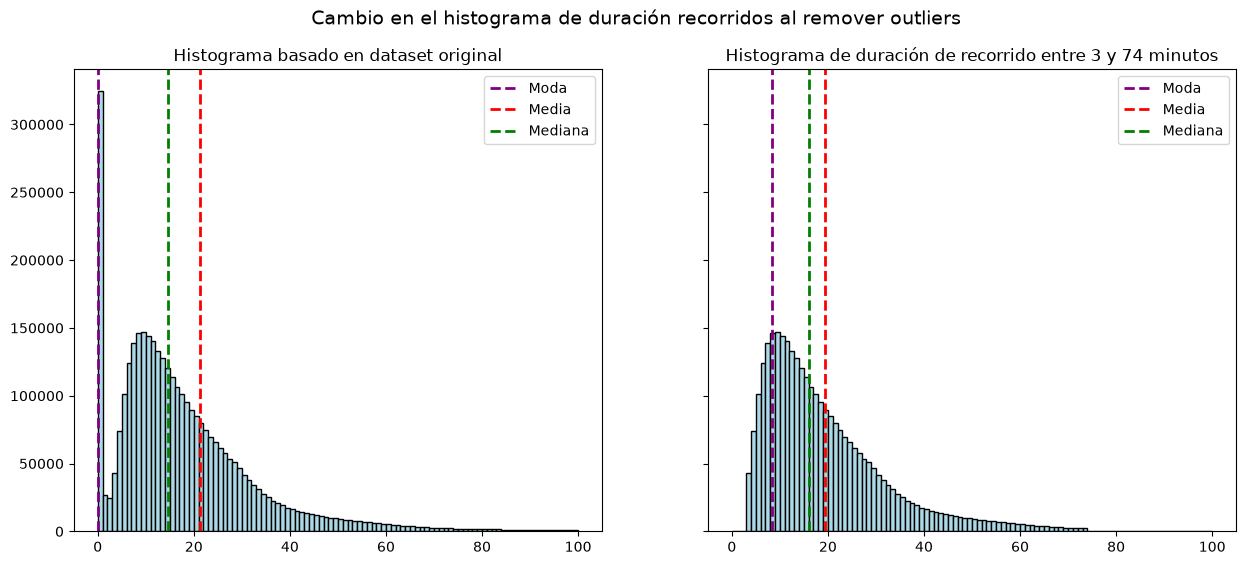

In [14]:
ecobici_filtrado_df = ecobici_df[(ecobici_df['duracion_recorrido'] > 3) & (ecobici_df['duracion_recorrido'] < 74)].copy()

fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
ax.flatten()

plt.suptitle('Cambio en el histograma de duración recorridos al remover outliers', fontsize=14)

plot_histograma(dataframe=ecobici_df, ax=ax[0], parametro='duracion_recorrido', titulo="Histograma basado en dataset original")
plot_histograma(dataframe=ecobici_filtrado_df, ax=ax[1], parametro='duracion_recorrido', titulo="Histograma de duración de recorrido entre 3 y 74 minutos")

In [15]:
print("Nuevas estadísticas con dataset sin outliers de duración de recorridos:")

print(f"Media: {ecobici_filtrado_df['duracion_recorrido'].mean()}, {aclaracion_tiempo(ecobici_filtrado_df['duracion_recorrido'].mean())}")
print(f"Mediana: {ecobici_filtrado_df['duracion_recorrido'].median()}, {aclaracion_tiempo(ecobici_filtrado_df['duracion_recorrido'].median())}")
for i, moda in enumerate(ecobici_filtrado_df['duracion_recorrido'].mode(), 1):
    tiempo_legible = aclaracion_tiempo(moda)
    print(f"Moda {i}: {moda} {tiempo_legible}")

# Estadística robusta
duracion_recorrido_Q1, duracion_recorrido_Q2, duracion_recorrido_Q3 = cuartiles(ecobici_filtrado_df['duracion_recorrido'])

print()
print("Estadística robusta:")
print("Q1 (25%):", duracion_recorrido_Q1, aclaracion_tiempo(duracion_recorrido_Q1))
print("Q2 (Mediana, 50%):", duracion_recorrido_Q2, aclaracion_tiempo(duracion_recorrido_Q2))
print("Q3 (75%):", duracion_recorrido_Q3, aclaracion_tiempo(duracion_recorrido_Q3))

print()
print(f"Asímetría de la variable 'duracion_recorrido': {ecobici_filtrado_df['duracion_recorrido'].skew():.4f}")
print(f"Curtosis de la variable 'duracion_recorrido': {ecobici_filtrado_df['duracion_recorrido'].kurtosis():.4f}")

Nuevas estadísticas con dataset sin outliers de duración de recorridos:
Media: 19.431454057806476, (19 minutos 25 segundos)
Mediana: 16.016666666666666, (16 minutos 0 segundos)
Moda 1: 8.333333333333334 (8 minutos 20 segundos)

Estadística robusta:
Q1 (25%): 10.016666666666667 (10 minutos 1 segundos)
Q2 (Mediana, 50%): 16.016666666666666 (16 minutos 0 segundos)
Q3 (75%): 25.233333333333334 (25 minutos 14 segundos)

Asímetría de la variable 'duracion_recorrido': 1.4378
Curtosis de la variable 'duracion_recorrido': 2.1823


Text(0.5, 1.0, 'Histograma luego de limpieza de duracion de recorridos')

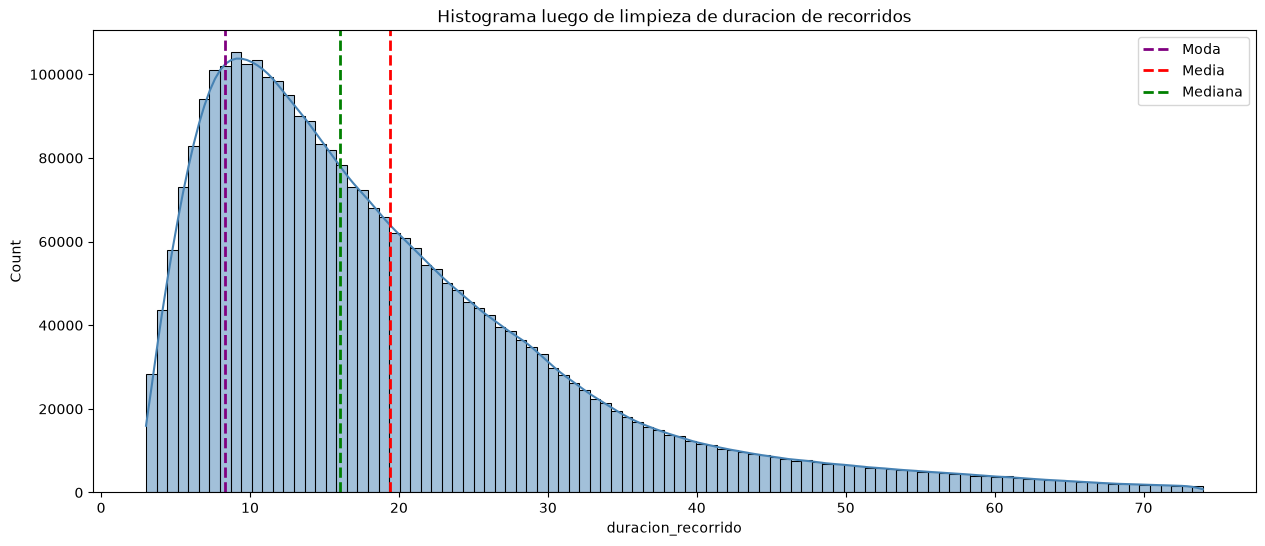

In [16]:
fig, ax = plt.subplots(figsize=(15, 6))

sns.histplot(ecobici_filtrado_df, x='duracion_recorrido', bins=100, kde=True, ax=ax, color='steelblue')
ax.axvline(ecobici_filtrado_df['duracion_recorrido'].mode()[0], color='purple', ls='--', lw=2, label='Moda')
ax.axvline(ecobici_filtrado_df['duracion_recorrido'].mean(), color='red', ls='--', lw=2, label='Media')
ax.axvline(ecobici_filtrado_df['duracion_recorrido'].median(), color='green', ls='--', lw=2, label='Mediana')
ax.legend()
ax.set_title("Histograma luego de limpieza de duracion de recorridos")

In [17]:
# Se asigna el dataframe limpio al dataframe original
ecobici_df = ecobici_filtrado_df

### Nulos

In [18]:
ecobici_df.isnull().sum()/len(ecobici_df)

id_recorrido                  0.000000
duracion_recorrido            0.000000
fecha_origen_recorrido        0.000000
id_estacion_origen            0.000000
nombre_estacion_origen        0.000000
direccion_estacion_origen     0.000000
long_estacion_origen          0.000000
lat_estacion_origen           0.000000
fecha_destino_recorrido       0.000000
id_estacion_destino           0.000000
nombre_estacion_destino       0.000000
direccion_estacion_destino    0.000000
long_estacion_destino         0.000000
lat_estacion_destino          0.000000
id_usuario                    0.000000
modelo_bicicleta              0.000000
genero                        0.003489
dtype: float64

Los nulos de genero son MAR. Como son muy pocos registros (0.3%), los eliminamos sin perder generalidad. 

In [19]:
ecobici_df = ecobici_df.dropna(subset=['genero'])

#### **Variable género**

In [20]:
def plot_pie(data, column, mapa_colores, ax=None, startangle=90, title=None):
    counts = data[column].value_counts()
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    
    # Mapeamos los colores en el mismo orden exacto en que quedaron las categorías en 'counts'
    colores_ordenados = [mapa_colores[cat] for cat in counts.index]
    
    ax.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=startangle,
        colors=colores_ordenados  # Usamos los colores sincronizados
    )
    ax.set_title(title if title else f'Distribución de "{column}"')
    ax.axis('equal')

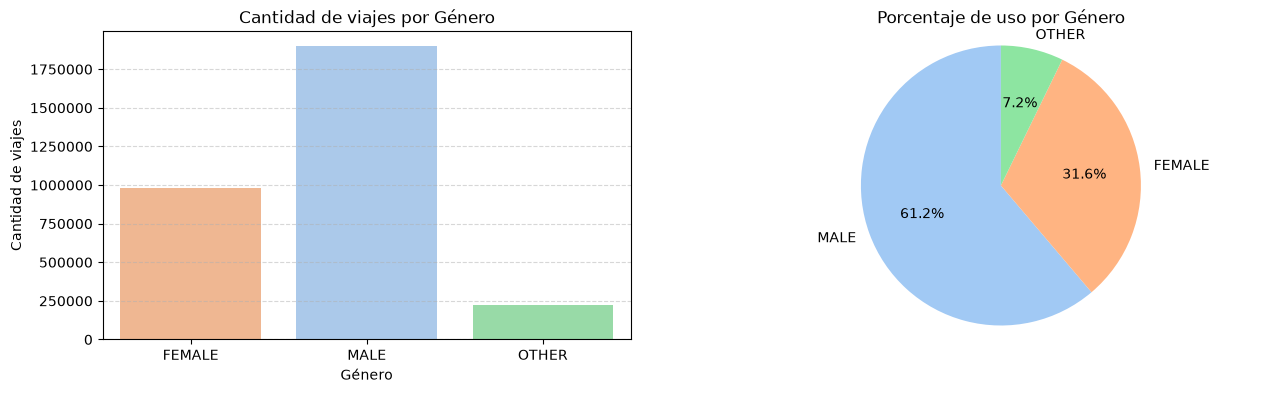

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes = axes.flatten()

paleta_base = sns.color_palette('pastel')

colores_genero = {
    'MALE':     paleta_base[0],
    'FEMALE':   paleta_base[1],
    'OTHER':    paleta_base[2]  
}

# Grafico 1: Barras
sns.countplot(
    x='genero', 
    data=ecobici_df, 
    hue='genero', 
    palette=colores_genero,
    ax=axes[0], 
    legend=False,
    dodge=False
)
axes[0].set_title('Cantidad de viajes por Género')
axes[0].set_xlabel('Género')
axes[0].set_ylabel('Cantidad de viajes')
axes[0].grid(axis='y', ls='--', alpha=0.5)
axes[0].ticklabel_format(style='plain', axis='y')

# Grafico 2: Pie chart
plot_pie(
    data=ecobici_df, 
    column='genero', 
    mapa_colores=colores_genero,
    ax=axes[1], 
    title='Porcentaje de uso por Género'
)

#### **Variable modelo de bicicleta**

In [22]:
print(ecobici_df['modelo_bicicleta'].value_counts())

modelo_bicicleta
FIT       2228090
ICONIC     874941
Name: count, dtype: int64


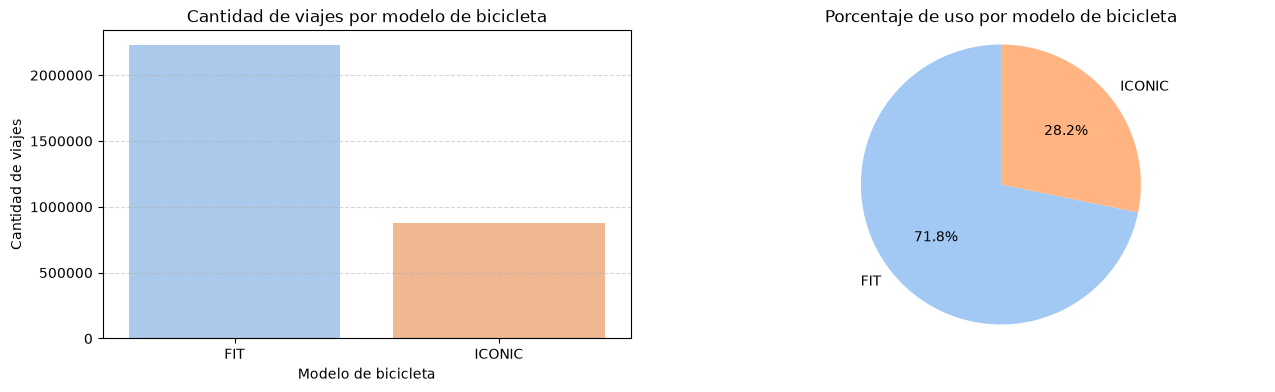

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes = axes.flatten()

paleta_base = sns.color_palette('pastel')

colores_bicicletas = {
    'FIT':     paleta_base[0],
    'ICONIC':   paleta_base[1],
}

# Grafico 1: Barras
sns.countplot(
    x='modelo_bicicleta', 
    data=ecobici_df, 
    hue='modelo_bicicleta', 
    palette=colores_bicicletas,
    ax=axes[0], 
    legend=False,
    dodge=False
)
axes[0].set_title('Cantidad de viajes por modelo de bicicleta')
axes[0].set_xlabel('Modelo de bicicleta')
axes[0].set_ylabel('Cantidad de viajes')
axes[0].grid(axis='y', ls='--', alpha=0.5)
axes[0].ticklabel_format(style='plain', axis='y')

# Grafico 2: Pie chart
plot_pie(
    data=ecobici_df, 
    column='modelo_bicicleta', 
    mapa_colores=colores_bicicletas,
    ax=axes[1], 
    title='Porcentaje de uso por modelo de bicicleta'
)

#### **Variables de estaciones de origen y destino**

Nota: los datos para graficar el contorno de CABA fueron descargados desde https://data.buenosaires.gob.ar/dataset/barrios/resource/1c3d185b-fdc9-474b-b41b-9bd960a3806e

In [24]:
# Se agrupan por estación de origen para tener coordenadas únicas y contar cuántos viajes salen de cada una
estaciones = (
    ecobici_df.groupby('nombre_estacion_origen')
    .agg(
        long=('long_estacion_origen', 'first'),
        lat=('lat_estacion_origen', 'first'),
        total_viajes=('id_recorrido', 'count')
    )
    .reset_index()
    .dropna() # por las dudas si hay alguna sin coordenadas
)

print(estaciones.head())

# Se crea la geometría de puntos geométricos espaciales
geometria = gpd.points_from_xy(estaciones['long'], estaciones['lat'])

# Se transforma a GeoDataFrame
geo_estaciones_gdf = gpd.GeoDataFrame(estaciones, geometry=geometria, crs="EPSG:4326")

# Se carga el mapa de los barrios de CABA
mapa_caba = gpd.read_file('./geojson/barrios.geojson')

      nombre_estacion_origen       long        lat  total_viajes
0          -CDO CUCHA CUCHA- -58.390287 -34.654474           228
1  001 - FACULTAD DE DERECHO -58.390602 -34.583749         26426
2             002 - Retiro I -58.374710 -34.592424          9602
3               003 - ADUANA -58.369129 -34.612207         15737
4           004 - Plaza Roma -58.368856 -34.603008         18593


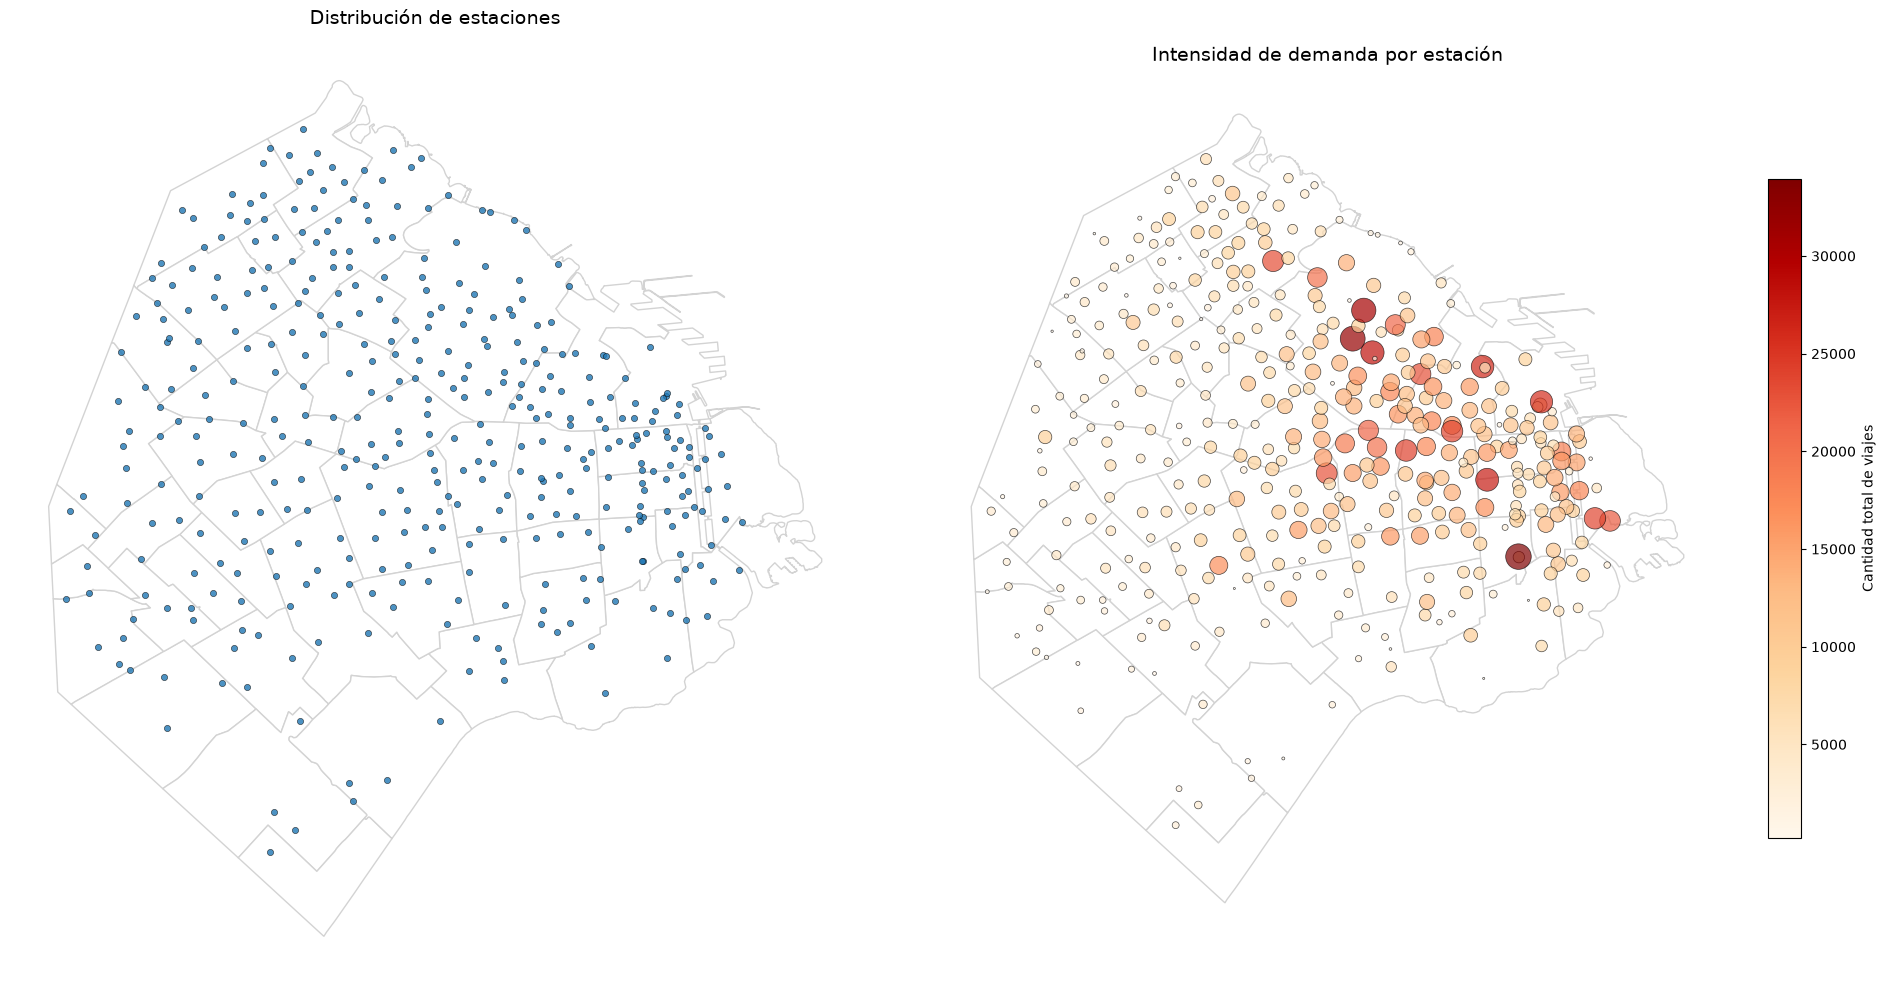

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Mapa 1: infraestructura. Se dibuja el fondo de CABA
mapa_caba.plot(ax=axes[0], color='white', edgecolor='lightgrey')

# Se dibujan las estaciones todas iguales
geo_estaciones_gdf.plot(
    ax=axes[0], 
    color='#1F77B4',
    markersize=20,   # Todos los puntos del mismo tamaño
    alpha=0.8, 
    edgecolor='black', 
    linewidth=0.4
)
axes[0].set_title('Distribución de estaciones', fontsize=14, pad=10)
axes[0].axis('off')  # Se sacan los ejes


# Mapa 2: mapa de calor (demanda de las estaciones). Se dibuja el fondo de CABA
mapa_caba.plot(ax=axes[1], color='white', edgecolor='lightgrey')

# Se dibuja el mapa de calor
geo_estaciones_gdf.plot(
    ax=axes[1], 
    column='total_viajes', 
    cmap='OrRd',       
    legend=True,       
    legend_kwds={'label': "Cantidad total de viajes", 'orientation': "vertical", 'shrink': 0.7},
    markersize=geo_estaciones_gdf['total_viajes'] / 100, # Ajustado para que no se pisen tanto
    alpha=0.7, 
    edgecolor='black', 
    linewidth=0.5
)
axes[1].set_title('Intensidad de demanda por estación', fontsize=14, pad=10)
axes[1].axis('off')  # Se sacan los ejes

plt.tight_layout()
plt.show()

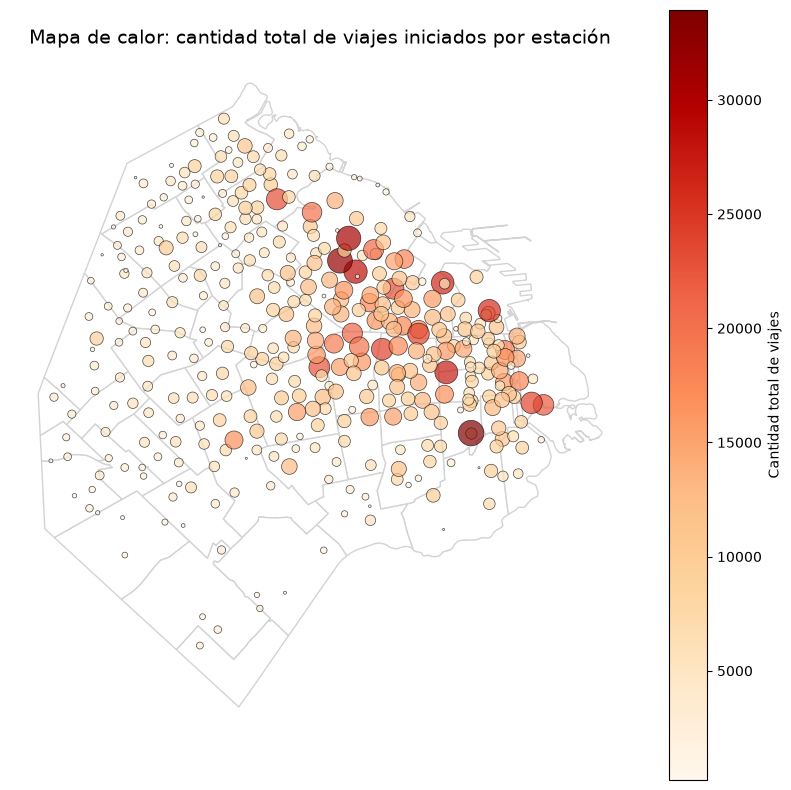

In [26]:
# Se crea el gráfico
fig, ax = plt.subplots(figsize=(10, 10))

# Se dibuja el fondo de los barrios en gris claro
mapa_caba.plot(ax=ax, color='white', edgecolor='lightgrey')

# Se dibujan las estaciones
geo_estaciones_gdf.plot(
    ax=ax, 
    column='total_viajes', 
    cmap='OrRd',       # Paleta de blanco a rojo oscuro
    legend=True,       # Muestra la barra de escala de colores
    markersize=geo_estaciones_gdf['total_viajes'] / 100, # Divisor para agrandar/achicar puntos
    legend_kwds={'label': "Cantidad total de viajes", 'orientation': "vertical"},
    alpha=0.7, 
    edgecolor='black', 
    linewidth=0.5
)

ax.set_title('Mapa de calor: cantidad total de viajes iniciados por estación', fontsize=14)
ax.axis('off') # Se saca los ejes de latitud y longitud

plt.show()

#### **Variables de fechas de los recorridos**

Se inicia la exploración de las fechas de los recorridos con la creación de algunas columnas necesarias para discernir: días, fechas, días de la semana de días de los fines de semana, días feriados, etc. Para ello, __solo se considerará la fecha origen de los viajes__ y se tomará como representativa del recorrido

In [27]:
# Conversion a datetime de fechas formato AAAA-MM-DD hh:mm
ecobici_df['fecha_origen_recorrido'] = pd.to_datetime(ecobici_df['fecha_origen_recorrido'])

C:\Users\panch\AppData\Local\Temp\ipykernel_30940\2332461670.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ecobici_df['fecha_origen_recorrido'] = pd.to_datetime(ecobici_df['fecha_origen_recorrido'])


In [28]:
# Creación de columnas nuevas con la fecha únicamente: se extrae AAAA-MM-DD
ecobici_df['fecha_origen'] = ecobici_df['fecha_origen_recorrido'].dt.date

# Creación de columnas para saber el día de la semana
ecobici_df['dia_de_la_semana_fecha_origen'] = ecobici_df['fecha_origen_recorrido'].dt.dayofweek

# Creación de columna categórica binaria para saber si es fin de semana (0 es lunes, 1 es martes,... 5 es sabado, 6 es domingo)
ecobici_df['fecha_origen_es_finde'] = ecobici_df['dia_de_la_semana_fecha_origen'].isin([5, 6])

# Creación de columna con el nombre del día (monday, tuesday, etc)
ecobici_df['nombre_del_dia_fecha_origen'] = ecobici_df['fecha_origen_recorrido'].dt.day_name()

C:\Users\panch\AppData\Local\Temp\ipykernel_30940\2890950304.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ecobici_df['fecha_origen'] = ecobici_df['fecha_origen_recorrido'].dt.date
C:\Users\panch\AppData\Local\Temp\ipykernel_30940\2890950304.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ecobici_df['dia_de_la_semana_fecha_origen'] = ecobici_df['fecha_origen_recorrido'].dt.dayofweek
C:\Users\panch\AppData\Local\Temp\ipykernel_30940\2890950304.py:8: SettingWithCopyWarning: 
A value is trying to be 

In [29]:
ecobici_df.head()

,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,...,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero,fecha_origen,dia_de_la_semana_fecha_origen,fecha_origen_es_finde,nombre_del_dia_fecha_origen
0,20428222,9.466667,2024-01-23 18:36:00,513,308 - SAN MARTIN II,Av. San Martín 5129,-58.490739,-34.597130,2024-01-23 18:45:28,498,...,Gral. José Gervasio Artigas 4298 (y Habana),-58.494959,-34.586598,992557.0,FIT,MALE,2024-01-23,1,False,Tuesday
1,20431744,22.583333,2024-01-23 22:41:20,460,133 - BEIRO Y SEGUROLA,Segurola 3194,-58.511930,-34.607500,2024-01-23 23:03:55,382,...,Biarritz 2403,-58.477255,-34.605431,320782.0,FIT,FEMALE,2024-01-23,1,False,Tuesday
4,20424802,11.333333,2024-01-23 15:18:39,137,137 - AZOPARDO Y CHILE,AZOPARDO 700,-58.367492,-34.615598,2024-01-23 15:29:59,150,...,Av. España 2200,-58.355465,-34.618755,861425.0,FIT,FEMALE,2024-01-23,1,False,Tuesday
5,20427241,7.766667,2024-01-23 17:48:05,99,099 - Malabia,780 Malabia & Loyola,-58.435408,-34.596096,2024-01-23 17:55:51,206,...,Fitz Roy & Gorriti,-58.437339,-34.584950,320714.0,FIT,OTHER,2024-01-23,1,False,Tuesday
6,20431004,19.600000,2024-01-23 21:17:38,68,105 - PARQUE SAAVEDRA,García del Río 3590,-58.480464,-34.552148,2024-01-23 21:37:14,68,...,García del Río 3590,-58.480464,-34.552148,1041602.0,ICONIC,MALE,2024-01-23,1,False,Tuesday


In [30]:
# Se cuentan cuántos viajes hubo por cada fecha individual, separando si fue finde o no
viajes_por_dia = ecobici_df.groupby(['fecha_origen', 'fecha_origen_es_finde']).size().reset_index(name='cantidad_viajes')

# Se calcula el promedio de viajes diarios para cada tipo de día
promedio_demanda = viajes_por_dia.groupby('fecha_origen_es_finde')['cantidad_viajes'].mean()

print("Promedio de viajes diarios")
print(f"Días Hábiles (Lunes a Viernes): {promedio_demanda[False]:.0f} viajes por día")
print(f"Fines de Semana (Sábado y Domingo): {promedio_demanda[True]:.0f} viajes por día")

Promedio de viajes diarios
Días Hábiles (Lunes a Viernes): 10352 viajes por día
Fines de Semana (Sábado y Domingo): 3758 viajes por día


Se encuentra que __en los días hábiles hay casi el triple de viajes diarios que los fines de semana__ (casi 12.000 contra 4.500).  
Una posible conclusión de este dato es que __Ecobici no es un sistema principalmente recreativo o turístico__, sino __parte del medio de transporte público para conmutar__. Los fines de semana la demanda se desplomaría ya que las personas no tienen que cumplir horarios laborales.

In [31]:
feriados_argentina_2024 = [
    '2024-01-01', # Año nuevo
    '2024-02-12', # Carnaval
    '2024-02-13', # Carnaval
    '2024-03-24', # Día Nacional de la Memoria por la Verdad y la Justicia
    '2024-03-28', # Jueves Santo
    '2024-03-29', # Viernes Santo
    '2024-04-01', # Feriado con fines turísticos
    '2024-04-02', # Día del Veterano y de los Caídos en la Guerra de Malvinas
    '2024-05-01', # Día del trabajo
    '2024-05-25', # Revolución de Mayo
    '2024-06-17', # Paso a la Inmortalidad del General Don Martín Miguel de Güemes
    '2024-06-20', # Paso a la Inmortalidad del General Don Manuel Belgrano
    '2024-06-21', # Feriado con fines turísticos
    '2024-07-09', # Día de la Independencia
    '2024-08-17', # Paso a la Inmortalidad del General Don José de San Martín
    '2024-10-11', # Feriado con fines turísticos
    '2024-11-18', # Día de la Soberanía
    '2024-12-25', # Navidad
]

feriados_argentina_2024_dates = pd.to_datetime(feriados_argentina_2024).date

# Se crea la columna en el dataset
ecobici_df['fecha_origen_es_feriado'] = ecobici_df['fecha_origen'].isin(feriados_argentina_2024_dates)

C:\Users\panch\AppData\Local\Temp\ipykernel_30940\1678409032.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ecobici_df['fecha_origen_es_feriado'] = ecobici_df['fecha_origen'].isin(feriados_argentina_2024_dates)


In [32]:
# Se crea una columna para indicar qué tipo de día es cada fecha origen
def etiquetar_tipo_dia_origen(row):
    if row['fecha_origen_es_feriado']:
        return 'Feriado'
    elif row['fecha_origen_es_finde']:
        return 'Fin de Semana'
    else:
        return 'Día Hábil'

ecobici_df['tipo_fecha_origen'] = ecobici_df.apply(etiquetar_tipo_dia_origen, axis=1)

C:\Users\panch\AppData\Local\Temp\ipykernel_30940\3812252590.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ecobici_df['tipo_fecha_origen'] = ecobici_df.apply(etiquetar_tipo_dia_origen, axis=1)


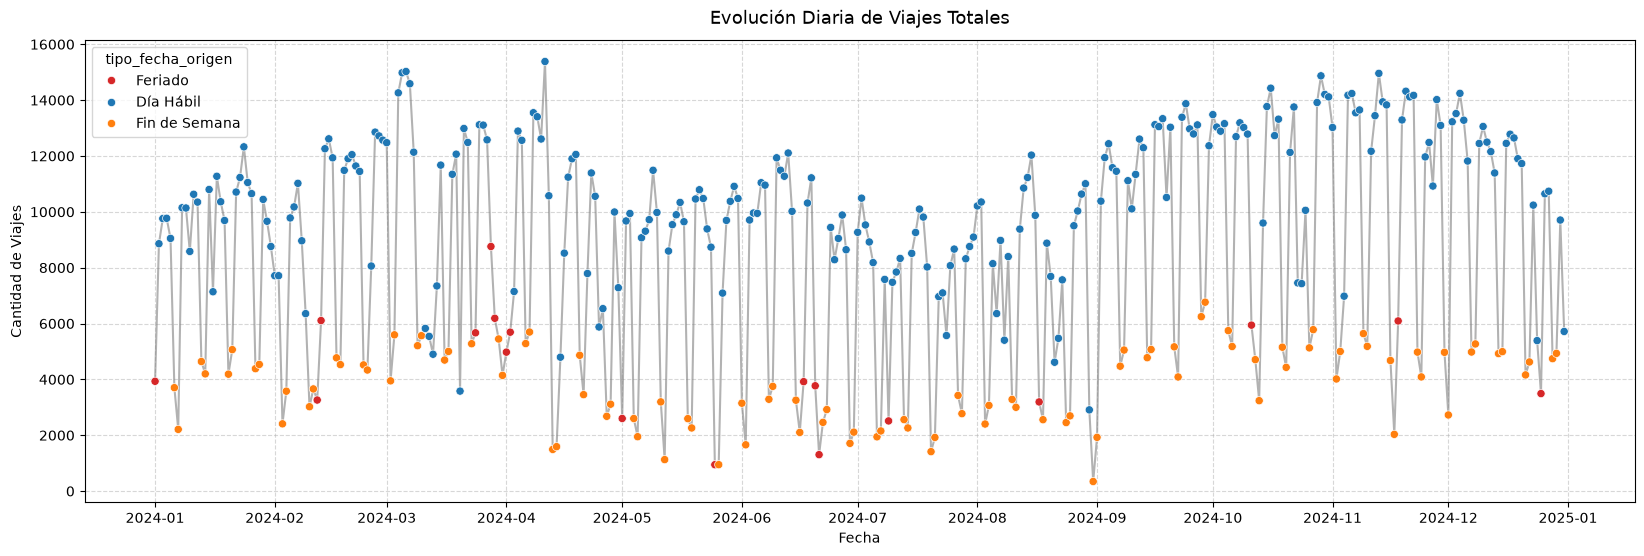

In [33]:
fig, ax = plt.subplots(figsize=(20, 6))

# Grafico 1: serie temporal. Cantidad de viajes por día distinguiendo:
# - Días de semana
# - Días de fin de semana
# - Días feriados
cantidad_de_viajes_por_dia_df = ecobici_df.groupby('fecha_origen').size().reset_index(name='cantidad_viajes')
cantidad_de_viajes_por_dia_df['fecha_origen'] = pd.to_datetime(cantidad_de_viajes_por_dia_df['fecha_origen'])

# Categorías para el gráfico de barras
tipos_de_dias = ['Día Hábil', 'Fin de Semana', 'Feriado']

sns.lineplot(
    data=cantidad_de_viajes_por_dia_df, 
    x='fecha_origen', 
    y='cantidad_viajes', 
    ax=ax, 
    color='grey', 
    alpha=0.6, 
    lw=1.5
)
# Puntos de color según el tipo de día
cantidad_de_viajes_por_dia_con_tipo_de_dia_df = ecobici_df.groupby(['fecha_origen', 'tipo_fecha_origen']).size().reset_index(name='cantidad_viajes')
cantidad_de_viajes_por_dia_con_tipo_de_dia_df['fecha_origen'] = pd.to_datetime(cantidad_de_viajes_por_dia_con_tipo_de_dia_df['fecha_origen'])

# Paleta de colores común para los dos gráficos a continuación
paleta_tipos_de_dias = {'Día Hábil': '#1F77B4', 'Fin de Semana': '#FF7F0E', 'Feriado': '#D62728'}
sns.scatterplot(
    data=cantidad_de_viajes_por_dia_con_tipo_de_dia_df, 
    x='fecha_origen', 
    y='cantidad_viajes', 
    hue='tipo_fecha_origen', 
    palette=paleta_tipos_de_dias, 
    ax=ax, 
    s=35, 
    zorder=3
)

# Mostrar divisiones cada un mes en el eje x
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))

ax.set_title('Evolución Diaria de Viajes Totales', fontsize=13, pad=12)
ax.set_xlabel('Fecha')
ax.set_ylabel('Cantidad de Viajes')
ax.grid(True, ls='--', alpha=0.5)

Observaciones
- Se nota una tendencia de disminución de viajes durante las épocas del centro del gráfico. Una posible hipótesis es que este comportamiento se deba a las bajas temperaturas (en época invernal los usuarios preferirían otros medios de transporte)
- La actividad durante los feriados y fines de semana decae de acuerdo a lo previamente calculado: en promedio la actividad durante días laborales es aproximadamente el triple que los días no laborables

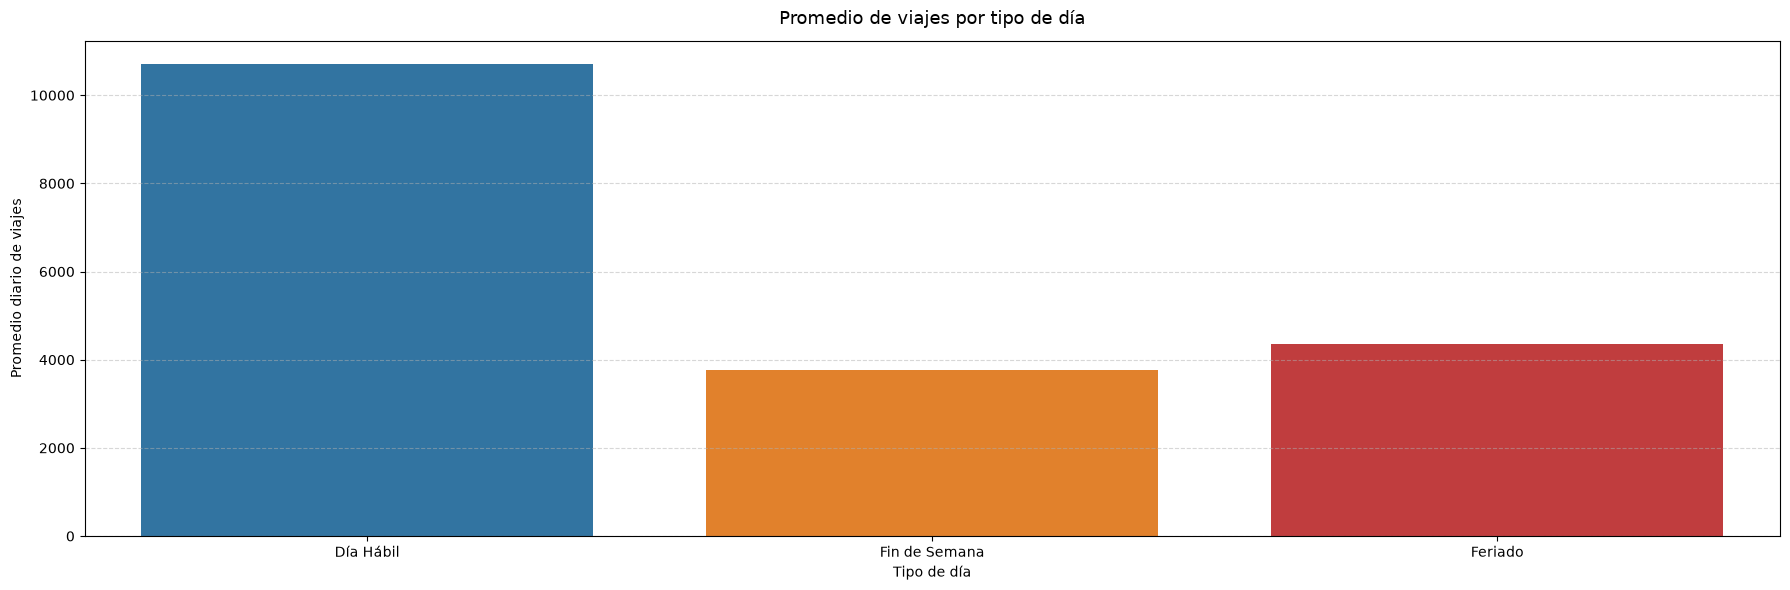

In [34]:
fig, ax = plt.subplots(figsize=(18, 6))

promedio_viajes_por_dia_df = ecobici_df.groupby(['fecha_origen', 'tipo_fecha_origen']).size().reset_index(name='cantidad_viajes')
promedios_por_tipo_de_dia_df = promedio_viajes_por_dia_df.groupby('tipo_fecha_origen')['cantidad_viajes'].mean().reset_index()

# Grafico 2: gráfico de barras por cantidad de viajes diferenciando por día
sns.barplot(
    data=promedios_por_tipo_de_dia_df, 
    x='tipo_fecha_origen', 
    y='cantidad_viajes', 
    order=tipos_de_dias, 
    palette=paleta_tipos_de_dias, 
    hue='tipo_fecha_origen',
    dodge=False,
    ax=ax,
    legend=False
)

ax.set_title('Promedio de viajes por tipo de día', fontsize=13, pad=12)
ax.set_xlabel('Tipo de día')
ax.set_ylabel('Promedio diario de viajes')
ax.grid(axis='y', ls='--', alpha=0.5)

# Ajustes generales
plt.tight_layout()
plt.show()

In [35]:
# Se extrae la hora del inicio de cada viaje y se agrega como columna
ecobici_df['hora_origen'] = ecobici_df['fecha_origen_recorrido'].dt.hour

# Se agrupa por fecha, tipo de día y hora para contar los viajes exactos
viajes_por_hora_df = ecobici_df.groupby(['fecha_origen', 'tipo_fecha_origen', 'hora_origen']).size().reset_index(name='cantidad_viajes')

# Se calcula el promedio diario de viajes para cada hora según el tipo de día (filtrando para comparar únicamente 'Día Hábil' vs 'Fin de Semana')
# promedio_horario_df = viajes_por_hora_df[viajes_por_hora_df['tipo_fecha_origen'].isin(['Día Hábil', 'Fin de Semana', ])].groupby(['tipo_fecha_origen', 'hora_origen'])['cantidad_viajes'].mean().reset_index()
# orden_dias
promedio_horario_df = viajes_por_hora_df.groupby(['tipo_fecha_origen', 'hora_origen'])['cantidad_viajes'].mean().reset_index()

promedio_horario_df.head()

C:\Users\panch\AppData\Local\Temp\ipykernel_30940\1102298864.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ecobici_df['hora_origen'] = ecobici_df['fecha_origen_recorrido'].dt.hour


,tipo_fecha_origen,hora_origen,cantidad_viajes
0,Día Hábil,0,181.858300
1,Día Hábil,1,116.125506
2,Día Hábil,2,61.267206
3,Día Hábil,3,33.178138
4,Día Hábil,4,36.704453


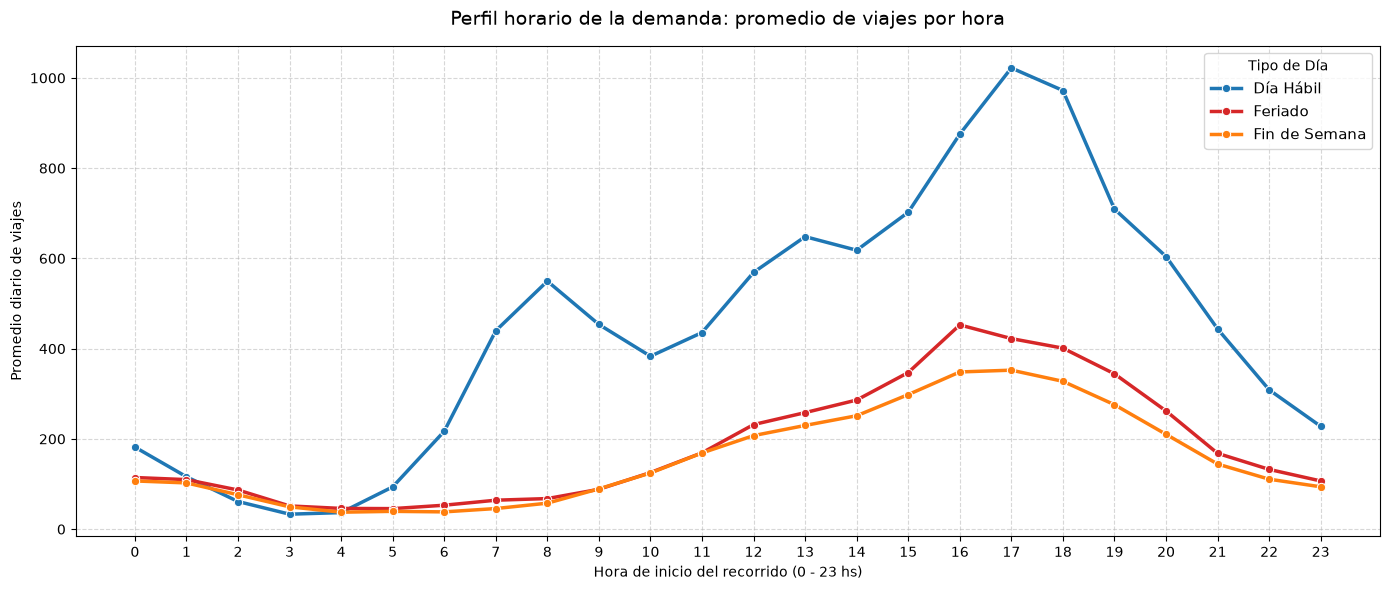

In [36]:
plt.figure(figsize=(14, 6))

# Se dibujan las líneas de tendencia horaria
sns.lineplot(
    data=promedio_horario_df, 
    x='hora_origen', 
    y='cantidad_viajes', 
    hue='tipo_fecha_origen', 
    palette=paleta_tipos_de_dias,
    lw=2.5,
    marker='o', # Le ponemos un puntito a cada hora para identificarla bien
    markersize=6
)

# Se fuerza a mostrar todas las horas de 0 a 23
plt.xticks(range(0, 24))

plt.grid(True, ls='--', alpha=0.5)
plt.title('Perfil horario de la demanda: promedio de viajes por hora', fontsize=14, pad=15)
plt.xlabel('Hora de inicio del recorrido (0 - 23 hs)')
plt.ylabel('Promedio diario de viajes')
plt.legend(title='Tipo de Día', fontsize=11)

plt.tight_layout()
plt.show()

Se observa:
- En días hábiles un pico en el uso cercano al horario de inicio laboral (8:00), luego otro pico alrededor del mediodía (13:00) y por último el mayor uso a la tarde (en torno a las 17:00)
- En días de fin de semana o feriados la dinámica es muy similar: existe un pico alrededor de las 16:00

Análisis de horario y su relación con las estaciones más concurridas

C:\Users\panch\AppData\Local\Temp\ipykernel_30940\896226028.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ecobici_df['franja_horaria_origen'] = ecobici_df['hora_origen'].apply(asignar_turno)


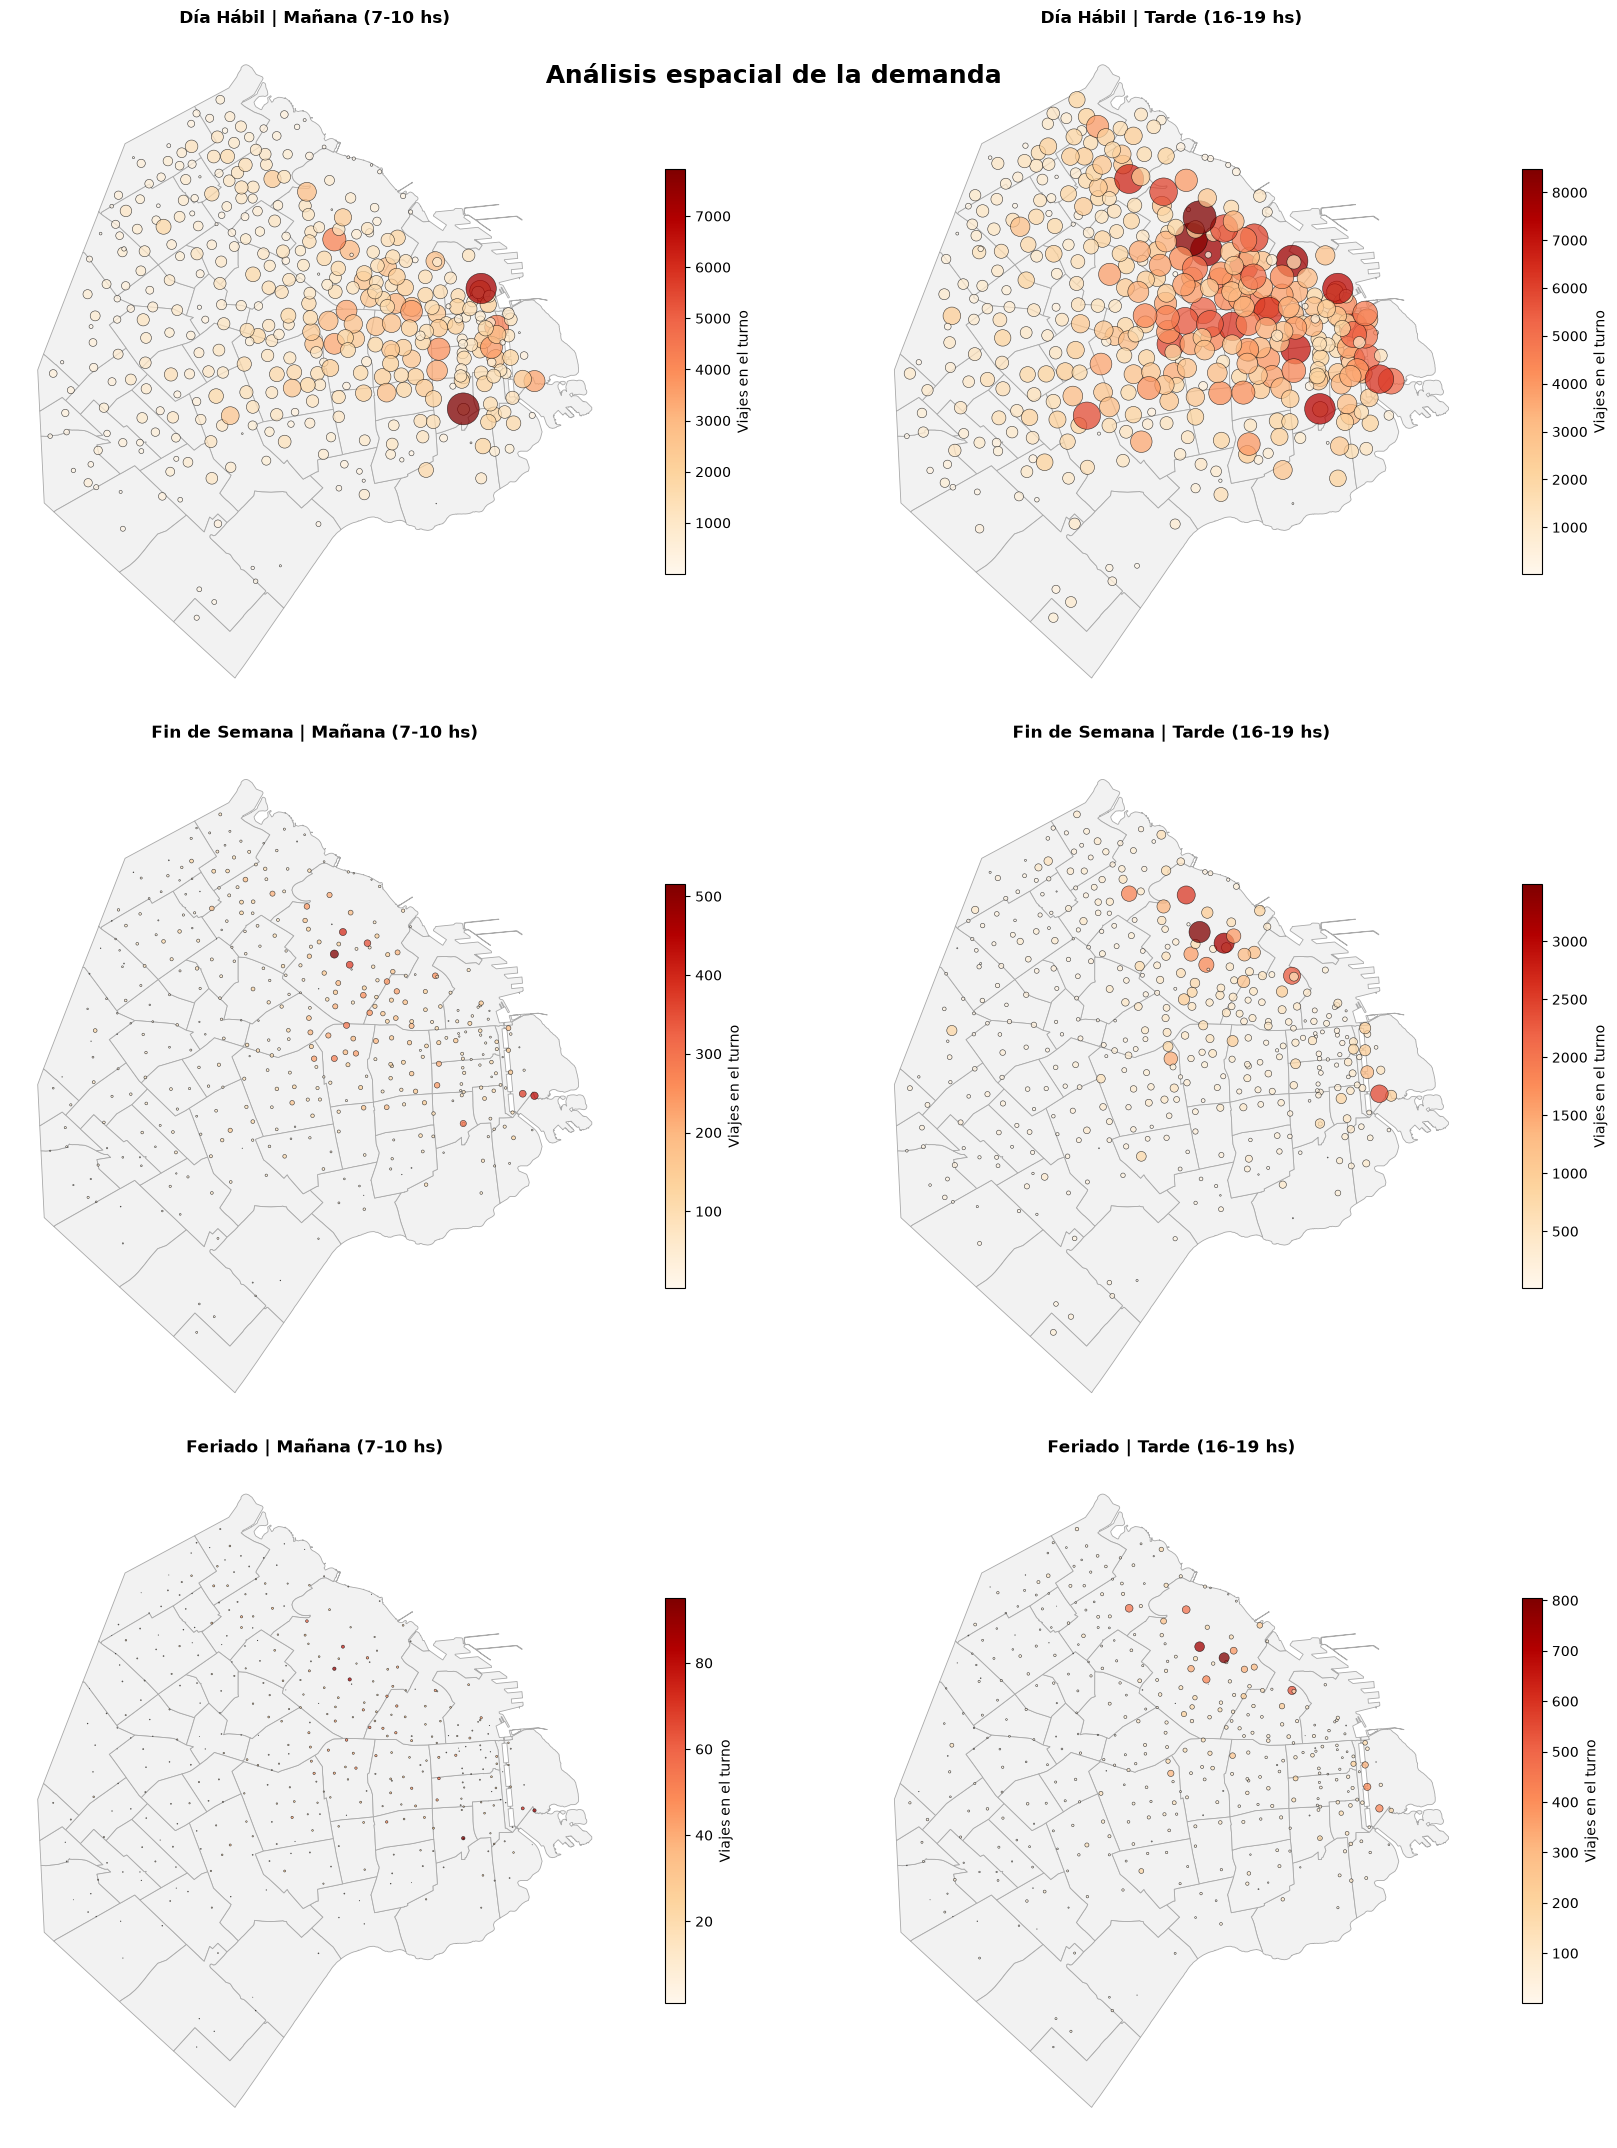

In [37]:
# Franjas horarias
def asignar_turno(hora):
    if 7 <= hora <= 10:
        return 'Mañana (7-10 hs)'
    elif 16 <= hora <= 19:
        return 'Tarde (16-19 hs)'
    else:
        return 'Otro'

ecobici_df['franja_horaria_origen'] = ecobici_df['hora_origen'].apply(asignar_turno)

# 6 mapas (3 filas x 2 columnas)
fig, axes = plt.subplots(3, 2, figsize=(18, 22))

# Matrices de iteración para los títulos y filtros
turnos = ['Mañana (7-10 hs)', 'Tarde (16-19 hs)']

# Generación de los 6 escenarios
for i, tipo_dia in enumerate(tipos_de_dias):
    for j, turno in enumerate(turnos):
        ax = axes[i, j]
        
        # Se filtra el dataset original para este escenario específico
        df_escenario = ecobici_df[(ecobici_df['tipo_fecha_origen'] == tipo_dia) & (ecobici_df['franja_horaria_origen'] == turno)]
        
        # Si el escenario está vacío, se salta al siguiente
        if df_escenario.empty:
            ax.set_title(f'{tipo_dia} - {turno} (Sin datos)')
            ax.axis('off')
            continue
            
        # Se agrupa por estación para este mapa en particular
        estaciones_escenario = (
            df_escenario.groupby('nombre_estacion_origen')
            .agg(
                long=('long_estacion_origen', 'first'),
                lat=('lat_estacion_origen', 'first'),
                viajes_periodo=('id_recorrido', 'count')
            )
            .reset_index()
            .dropna()
        )
        
        # Se convierte a GeoDataFrame
        geom = gpd.points_from_xy(estaciones_escenario['long'], estaciones_escenario['lat'])
        geo_estaciones_escenario_gdf = gpd.GeoDataFrame(estaciones_escenario, geometry=geom, crs="EPSG:4326")
        
        # Dibujado del mapa: fondo de CABA fijo
        mapa_caba.plot(ax=ax, color='#F2F2F2', edgecolor='darkgrey', linewidth=0.6)
        
        # Capa de puntos
        geo_estaciones_escenario_gdf.plot(
            ax=ax,
            column='viajes_periodo',
            cmap='OrRd',
            legend=True,
            legend_kwds={'label': "Viajes en el turno", 'orientation': "vertical", 'shrink': 0.6},
            # Se ajusta el tamaño relativo
            markersize=geo_estaciones_escenario_gdf['viajes_periodo'] / 15, 
            alpha=0.75,
            edgecolor='black',
            linewidth=0.4
        )
        
        # Título dinámico para cada uno de los 6 cuadrantes
        ax.set_title(f'{tipo_dia} | {turno}', fontsize=12, pad=8, fontweight='bold')
        ax.axis('off')

plt.suptitle('Análisis espacial de la demanda', fontsize=18, y=0.95, fontweight='bold')
plt.tight_layout()
plt.show()

## Análisis de variables

In [38]:
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import OrdinalEncoder

# Extracción de componentes temporales numéricos
ecobici_df['fecha_origen_recorrido'] = pd.to_datetime(ecobici_df['fecha_origen_recorrido'])
ecobici_df['hora_origen'] = ecobici_df['fecha_origen_recorrido'].dt.hour
ecobici_df['dia_semana'] = ecobici_df['fecha_origen_recorrido'].dt.dayofweek
ecobici_df['es_fin_de_semana'] = ecobici_df['dia_semana'].isin([5, 6]).astype(int)

ecobici_df['duracion_minutos'] = ecobici_df['duracion_recorrido']

# Cálculo de Distancia en Línea recta en km entre estaciones
def calcular_haversine(lat1, lon1, lat2, lon2):
    R = 6371.0  # Radio de la Tierra en km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

ecobici_df['distancia_km'] = calcular_haversine(
    ecobici_df['lat_estacion_origen'], ecobici_df['long_estacion_origen'],
    ecobici_df['lat_estacion_destino'], ecobici_df['long_estacion_destino']
)

# Limpieza rápida de nulos en las variables
df_analisis = ecobici_df.dropna(subset=['duracion_minutos', 'distancia_km', 'genero', 'modelo_bicicleta']).copy()

tamanio_muestra = min(40000, len(df_analisis))
df_muestra = df_analisis.sample(n=tamanio_muestra, random_state=42)

print(f"Muestra lista para análisis estadístico: {df_muestra.shape[0]} filas extraídas con éxito.")

C:\Users\panch\AppData\Local\Temp\ipykernel_30940\1447800435.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ecobici_df['fecha_origen_recorrido'] = pd.to_datetime(ecobici_df['fecha_origen_recorrido'])
C:\Users\panch\AppData\Local\Temp\ipykernel_30940\1447800435.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ecobici_df['hora_origen'] = ecobici_df['fecha_origen_recorrido'].dt.hour
C:\Users\panch\AppData\Local\Temp\ipykernel_30940\1447800435.py:9: SettingWithCopyWarning: 
A value is trying to be set o

Muestra lista para análisis estadístico: 40000 filas extraídas con éxito.


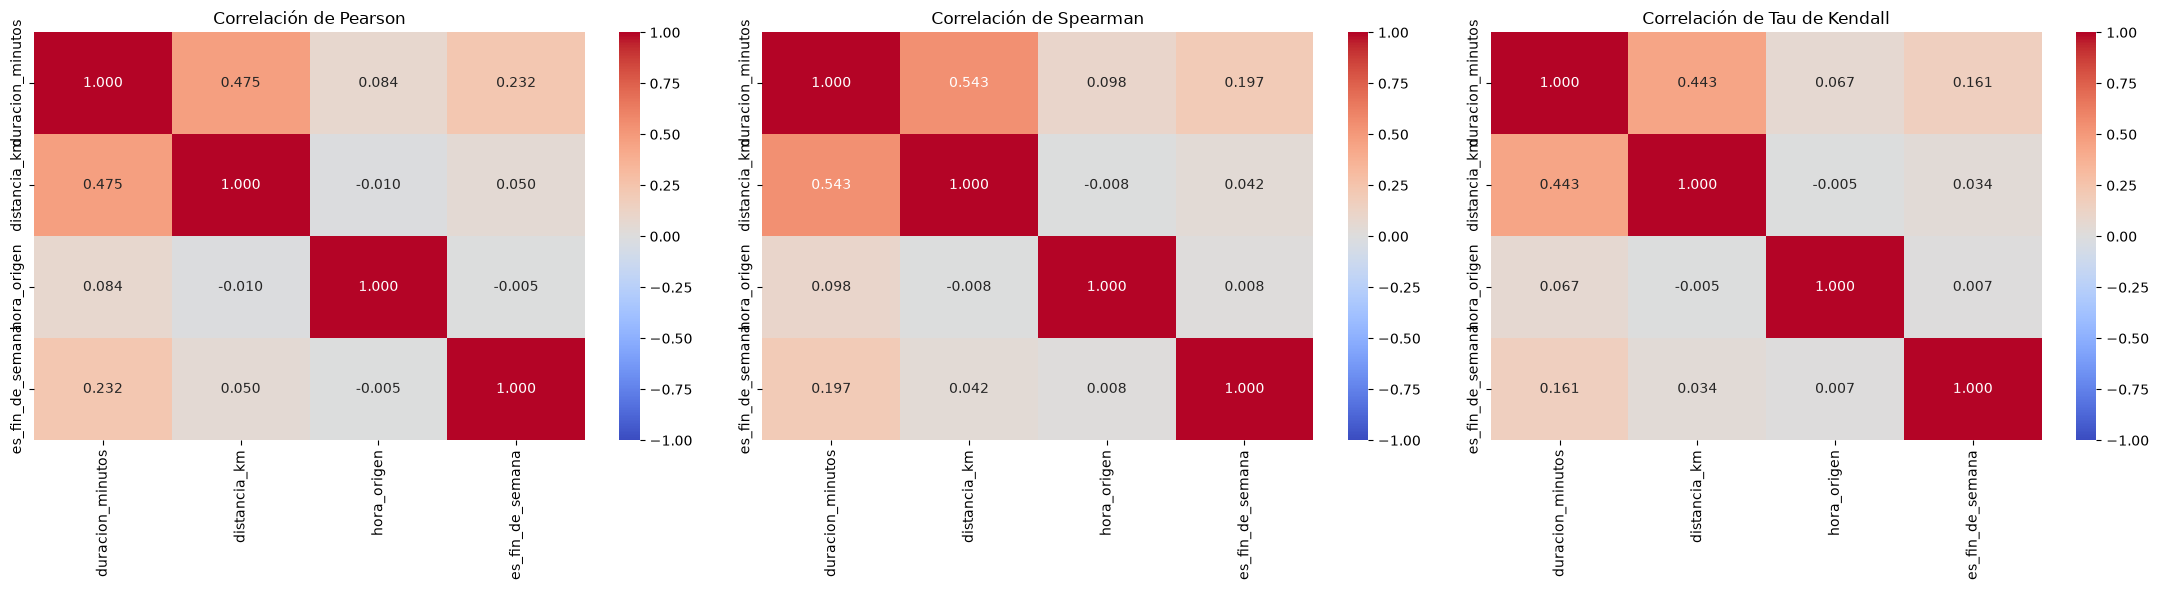

In [39]:
vars_numericas = ['duracion_minutos', 'distancia_km', 'hora_origen', 'es_fin_de_semana']

# Pearson (Tendencias Lineales) Y Kendall (Robusta a Outliers - monotónica no paramétrica) Y Spearman (Rangos - monotónica no paramétrica)
corr_pearson = df_muestra[vars_numericas].corr(method='pearson')
corr_spearman = df_muestra[vars_numericas].corr(method='spearman')
corr_kendall = df_muestra[vars_numericas].corr(method='kendall')

# Mapas de calor (Heatmaps)
fig, ax = plt.subplots(1, 3, figsize=(22, 6))

sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1, ax=ax[0])
ax[0].set_title("Correlación de Pearson")

sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1, ax=ax[1])
ax[1].set_title("Correlación de Spearman")

sns.heatmap(corr_kendall, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1, ax=ax[2])
ax[2].set_title("Correlación de Tau de Kendall")

plt.tight_layout()
plt.show()

Según vemos con Pearson hay una relación lineal entre distancia_km y duracion_minutos que es relativamente fuerte. Esto tiene sentido ya que a mayor distancia recorrida, mayor tiempo toma. Sin embargo, la relación no es perfecta, lo que se puede deber a distintos factores: por ejemplo, el tráfico, la cantidad de semáforos en el camino, etc. Donde más se nota esta relación es en el gráfico de Spearman lo que indica que la relación entre estas variables es monotónica, aunque no necesariamente lineal. Esto también tiene sentido, ya que a medida que aumenta la distancia, la duración del recorrido también tiende a aumentar, pero no de manera estrictamente lineal debido a los factores mencionados anteriormente.

Se puede ver también una muy ligera relación entre es_fin_de_semana con duracion_minutos (de manera más notoria) y también con distancia_km y hora_origen. Esto también tiene sentido, ya que los fines de semana y las horas pico suelen ser momentos de mayor tráfico, lo que puede aumentar la duración de los recorridos.

El gráfico en el que las relaciones están más marcadas es el de Spearman indicando una relación monotónica entre las variables, aunque no necesariamente lineal.

C:\Users\panch\AppData\Local\Temp\ipykernel_30940\266593454.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MI Score', y='Variable', data=df_mi, palette='viridis')


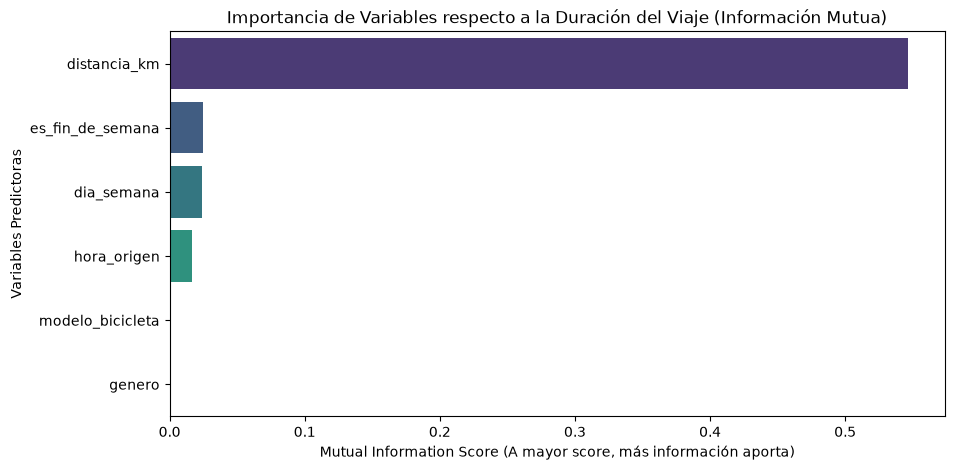


Tabla de scores:
        Variable  MI Score
    distancia_km  0.546287
es_fin_de_semana  0.024379
      dia_semana  0.024217
     hora_origen  0.016202
modelo_bicicleta  0.000000
          genero  0.000000


In [40]:
# Variables predictoras evaluadas contra el Target
features_mi = ['distancia_km', 'hora_origen', 'dia_semana', 'es_fin_de_semana', 'modelo_bicicleta', 'genero']
X = df_muestra[features_mi].copy()
y = df_muestra['duracion_minutos']

# Variables de textos (modelo_bicicleta, genero) codificadas a números para que scikit-learn los acepte
encoder = OrdinalEncoder()
X[['modelo_bicicleta', 'genero']] = encoder.fit_transform(X[['modelo_bicicleta', 'genero']].astype(str))

# Indicamos cuáles variables son discretas (True) y cuáles continuas (False)
# Orden: ['distancia_km'(F), 'hora_origen'(T), 'dia_semana'(T), 'es_fin_de_semana'(T), 'modelo_bicicleta'(T), 'genero'(T)]
mascara_discretas = [False, True, True, True, True, True]

# Ejecutamos la función de Información Mutua para Regresión
mi_scores = mutual_info_regression(X, y, discrete_features=mascara_discretas, random_state=42)

# Convertimos los resultados a un DataFrame ordenado para graficarlo fácilmente
df_mi = pd.DataFrame({'Variable': features_mi, 'MI Score': mi_scores}).sort_values(by='MI Score', ascending=False)

# Graficamos los resultados
plt.figure(figsize=(10, 5))
sns.barplot(x='MI Score', y='Variable', data=df_mi, palette='viridis')
plt.title("Importancia de Variables respecto a la Duración del Viaje (Información Mutua)")
plt.xlabel("Mutual Information Score (A mayor score, más información aporta)")
plt.ylabel("Variables Predictoras")
plt.show()

print("\nTabla de scores:")
print(df_mi.to_string(index=False))

Como se puede ver en la tabla superior la variable que más se relaciona con la duración del recorrido es la distancia recorrida. Esto tiene sentido, ya que a mayor distancia recorrida, mayor tiempo toma el viaje, como habíamos visto anteriormente con Pearson y con Kendall.

También influye si es día de la semana o fin de semana y la hora de origen, aunque en menor medida. Esto también tiene sentido, ya que los fines de semana y las horas pico suelen ser momentos de mayor tráfico, lo que puede aumentar la duración de los recorridos.

Por otro lado, el modelo_bicicleta y genero tienen un score de 0, lo que indica que no tienen relación con la duración del recorrido. Esto también tiene sentido, ya que el modelo de bicicleta y el género del usuario no deberían influir en la duración del recorrido.

### Scatterplot

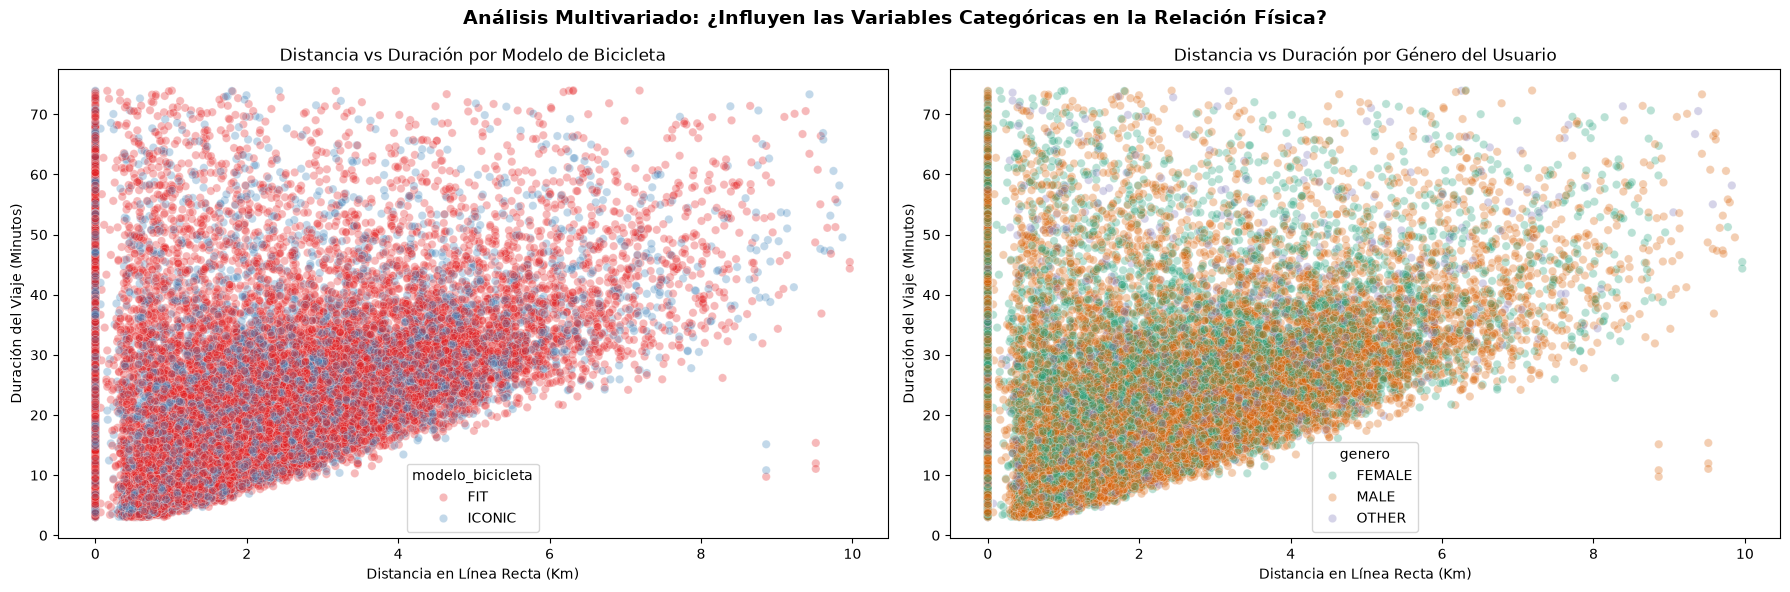

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy

# Filtramos visualmente SOLO PARA LOS GRÁFICOS para evitar que los outliers rompan la escala
df_vis = df_muestra[(df_muestra['duracion_minutos'] < 90) & (df_muestra['distancia_km'] < 10)].copy()

# GRAFICO SCATTERPLOT MULTIVARIADO (Distancia vs Duración por Modelo/Género)
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.scatterplot(data=df_vis, x='distancia_km', y='duracion_minutos', hue='modelo_bicicleta', alpha=0.3, palette='Set1', ax=ax[0])
ax[0].set_title("Distancia vs Duración por Modelo de Bicicleta", fontsize=12)
ax[0].set_xlabel("Distancia en Línea Recta (Km)")
ax[0].set_ylabel("Duración del Viaje (Minutos)")

sns.scatterplot(data=df_vis, x='distancia_km', y='duracion_minutos', hue='genero', alpha=0.3, palette='Dark2', ax=ax[1])
ax[1].set_title("Distancia vs Duración por Género del Usuario", fontsize=12)
ax[1].set_xlabel("Distancia en Línea Recta (Km)")
ax[1].set_ylabel("Duración del Viaje (Minutos)")

plt.suptitle("Análisis Multivariado: ¿Influyen las Variables Categóricas en la Relación Física?", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\panch\AppData\Local\Temp\ipykernel_30940\329308253.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_resumen_dias, x='dia_nombre', y='median', palette='Blues_d', ax=ax[0])
C:\Users\panch\AppData\Local\Temp\ipykernel_30940\329308253.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_resumen_dias, x='dia_nombre', y='mean', palette='Oranges_d', ax=ax[1])


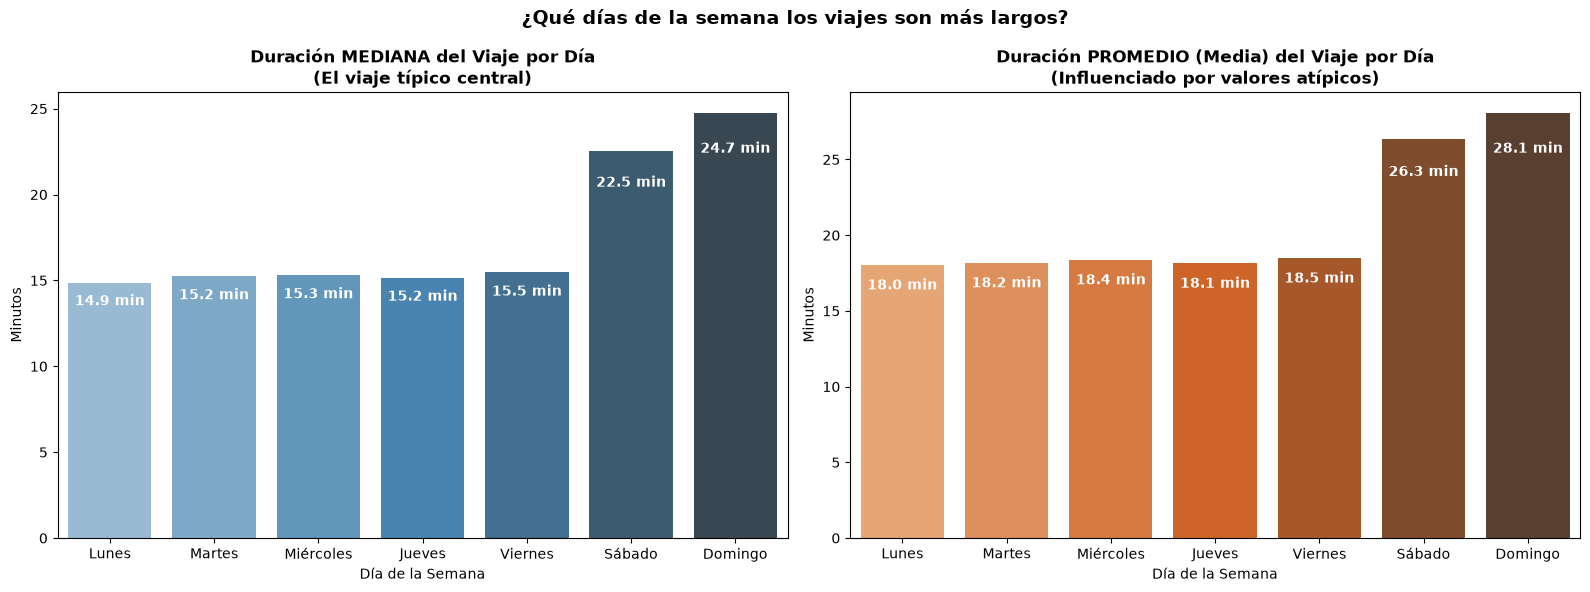

Valores exactos obtenidos:
dia_nombre      mean    median
     Lunes 18.016869 14.866667
    Martes 18.175662 15.250000
 Miércoles 18.392776 15.316667
    Jueves 18.142913 15.158333
   Viernes 18.523633 15.483333
    Sábado 26.343281 22.533333
   Domingo 28.053479 24.733333


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dias_semana_nombres = {
    0: 'Lunes', 
    1: 'Martes', 
    2: 'Miércoles', 
    3: 'Jueves', 
    4: 'Viernes', 
    5: 'Sábado', 
    6: 'Domingo'
}
df_muestra['dia_nombre'] = df_muestra['dia_semana'].map(dias_semana_nombres)

orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
df_resumen_dias = df_muestra.groupby('dia_nombre')['duracion_minutos'].agg(['mean', 'median']).reindex(orden_dias).reset_index()

fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

# Gráfico Izquierdo: Mediana (El viaje típico, robusto a outliers)
sns.barplot(data=df_resumen_dias, x='dia_nombre', y='median', palette='Blues_d', ax=ax[0])
ax[0].set_title("Duración MEDIANA del Viaje por Día\n(El viaje típico central)", fontsize=12, fontweight='bold')
ax[0].set_xlabel("Día de la Semana")
ax[0].set_ylabel("Minutos")
for p in ax[0].patches:
    ax[0].annotate(f"{p.get_height():.1f} min", (p.get_x() + p.get_width() / 2., p.get_height() * 0.9),
                ha='center', va='center', color='white', fontweight='bold', xytext=(0, 5), textcoords='offset points')

# Gráfico Derecho: Media (Promedio, inflado por outliers)
sns.barplot(data=df_resumen_dias, x='dia_nombre', y='mean', palette='Oranges_d', ax=ax[1])
ax[1].set_title("Duración PROMEDIO (Media) del Viaje por Día\n(Influenciado por valores atípicos)", fontsize=12, fontweight='bold')
ax[1].set_xlabel("Día de la Semana")
ax[1].set_ylabel("Minutos")
for p in ax[1].patches:
    ax[1].annotate(f"{p.get_height():.1f} min", (p.get_x() + p.get_width() / 2., p.get_height() * 0.9),
                ha='center', va='center', color='white', fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.suptitle("¿Qué días de la semana los viajes son más largos?", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Valores exactos obtenidos:")
print(df_resumen_dias.to_string(index=False))

In [43]:
## Cálculo de la entropía de Shannon para las variables categóricas
def calcular_entropia_shannon(columna):
    probabilidades = columna.value_counts(normalize=True)
    return entropy(probabilidades, base=2)

print("ENTROPÍA DE SHANNON")
print(f"Entropía en 'modelo_bicicleta': {calcular_entropia_shannon(df_muestra['modelo_bicicleta']):.3f} bits")
print(f"Entropía en 'genero': {calcular_entropia_shannon(df_muestra['genero']):.3f} bits")
print(f"Entropía en 'es_fin_de_semana': {calcular_entropia_shannon(df_muestra['es_fin_de_semana']):.3f} bits")

ENTROPÍA DE SHANNON
Entropía en 'modelo_bicicleta': 0.858 bits
Entropía en 'genero': 1.234 bits
Entropía en 'es_fin_de_semana': 0.548 bits


C:\Users\panch\AppData\Local\Temp\ipykernel_30940\2842532698.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_resumen_feriados, x='es_feriado', y='median', palette='Purples_d', ax=ax[0])
C:\Users\panch\AppData\Local\Temp\ipykernel_30940\2842532698.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_resumen_feriados, x='es_feriado', y='mean', palette='Reds_d', ax=ax[1])


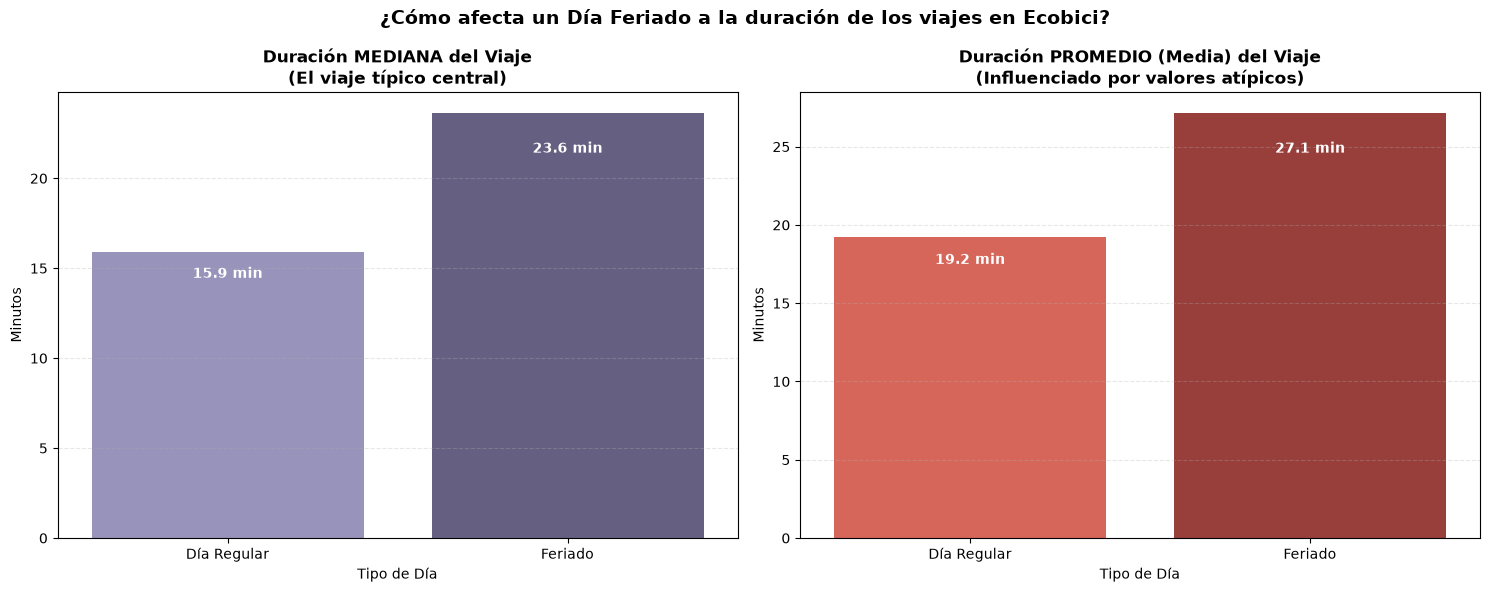

Valores exactos obtenidos para Feriados vs Días Regulares:
 es_feriado      mean    median
Día Regular 19.237932 15.883333
    Feriado 27.133684 23.616667


In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_analisis['fecha_solo'] = df_analisis['fecha_origen_recorrido'].dt.strftime('%Y-%m-%d')


df_analisis['es_feriado'] = df_analisis['fecha_solo'].apply(lambda x: 'Feriado' if x in feriados_argentina_2024  else 'Día Regular')

df_resumen_feriados = df_analisis.groupby('es_feriado')['duracion_minutos'].agg(['mean', 'median']).reset_index()

fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharey=False)

# Gráfico Izquierdo: Mediana (El viaje típico, robusto a outliers)
sns.barplot(data=df_resumen_feriados, x='es_feriado', y='median', palette='Purples_d', ax=ax[0])
ax[0].set_title("Duración MEDIANA del Viaje\n(El viaje típico central)", fontsize=12, fontweight='bold')
ax[0].set_xlabel("Tipo de Día")
ax[0].set_ylabel("Minutos")
ax[0].grid(axis='y', ls='--', alpha=0.3)
for p in ax[0].patches:
    ax[0].annotate(f"{p.get_height():.1f} min", (p.get_x() + p.get_width() / 2., p.get_height() * 0.9),
                ha='center', va='center', color='white', fontweight='bold', xytext=(0, 5), textcoords='offset points')

# Gráfico Derecho: Media (Promedio, inflado por outliers)
sns.barplot(data=df_resumen_feriados, x='es_feriado', y='mean', palette='Reds_d', ax=ax[1])
ax[1].set_title("Duración PROMEDIO (Media) del Viaje\n(Influenciado por valores atípicos)", fontsize=12, fontweight='bold')
ax[1].set_xlabel("Tipo de Día")
ax[1].set_ylabel("Minutos")
ax[1].grid(axis='y', ls='--', alpha=0.3)
for p in ax[1].patches:
    ax[1].annotate(f"{p.get_height():.1f} min", (p.get_x() + p.get_width() / 2., p.get_height() * 0.9),
                ha='center', va='center', color='white', fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.suptitle("¿Cómo afecta un Día Feriado a la duración de los viajes en Ecobici?", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Valores exactos obtenidos para Feriados vs Días Regulares:")
print(df_resumen_feriados.to_string(index=False))

## Planteo de problema de ML

Como posible problema de ML se plantea __un problema de regresión__. La variable target será __"duración_recorrido"__, es decir, se tratará de predecir la duración de un viaje conocidas las otras variables.

## Feature engineering


> **Importante:** solo se usan datos disponibles en el **momento de inicio del viaje**.  
> La estación de destino se conoce recién cuando termina el recorrido, por lo que incluirla  
> (o cualquier feature derivada de ella, como `distancia_haversine_km` o `mismo_id_estacion`) sería **data leakage**.

| Feature nueva | Fuente | Motivo |
|---|---|---|
| `hora_origen` | `fecha_origen_recorrido` | La hora del día influye en el tráfico y la duración del viaje |
| `mes_origen` | `fecha_origen_recorrido` | Estacionalidad (verano / invierno en Buenos Aires) |
| `dia_semana` | `fecha_origen_recorrido` | Distinto patrón laborable vs. fin de semana |
| `es_finde` | `dia_semana` | Feature binaria de uso frecuente en modelos |
| `es_feriado` | Lista de feriados 2024 | Los feriados se comportan similar a fines de semana |
| `tipo_dia` | `es_finde` + `es_feriado` | Categoría combinada: Hábil / Fin de Semana / Feriado |
| `franja_horaria` | `hora_origen` | Mañana / Mediodía / Tarde / Noche: segmenta mejor que la hora continua |

In [50]:
df = ecobici_filtrado_df.copy()

# ─── Parsear fechas ───────────────────────────────────────────────────────────
df['fecha_origen_dt'] = pd.to_datetime(
    df['fecha_origen_recorrido'].astype(str), errors='coerce'
)

# ─── Features temporales ──────────────────────────────────────────────────────
df['hora_origen']    = df['fecha_origen_dt'].dt.hour
df['mes_origen']     = df['fecha_origen_dt'].dt.month
df['dia_semana']     = df['fecha_origen_dt'].dt.dayofweek   # 0=Lun, 6=Dom
df['fecha_origen_d'] = df['fecha_origen_dt'].dt.date        # solo fecha

df['es_finde'] = df['dia_semana'].isin([5, 6])

# ─── Feriados argentinos 2024 ─────────────────────────────────────────────────
feriados_2024 = [
    '2024-01-01', '2024-02-12', '2024-02-13', '2024-03-24',
    '2024-03-28', '2024-03-29', '2024-04-01', '2024-04-02',
    '2024-05-01', '2024-05-25', '2024-06-17', '2024-06-20',
    '2024-06-21', '2024-07-09', '2024-08-17', '2024-10-11',
    '2024-11-18', '2024-12-25',
]
feriados_dates = pd.to_datetime(feriados_2024).date
df['es_feriado'] = df['fecha_origen_d'].isin(feriados_dates)

def etiquetar_tipo_dia(row):
    if row['es_feriado']:
        return 'Feriado'
    elif row['es_finde']:
        return 'Fin de Semana'
    else:
        return 'Día Hábil'

df['tipo_dia'] = df.apply(etiquetar_tipo_dia, axis=1)

# ─── Franja horaria ───────────────────────────────────────────────────────────
def franja_horaria(hora):
    if 6 <= hora < 12:
        return 'Mañana'
    elif 12 <= hora < 17:
        return 'Tarde'
    elif 17 <= hora < 21:
        return 'Tarde-Noche'
    else:
        return 'Noche'

df['franja_horaria'] = df['hora_origen'].apply(franja_horaria)

print('Features temporales creadas.')

Features temporales creadas.


In [ ]:
# ─── Vista previa de las nuevas columnas ──────────────────────────────────────
nuevas_cols = [
    'duracion_recorrido',
    'hora_origen', 'mes_origen', 'dia_semana',
    'es_finde', 'es_feriado', 'tipo_dia', 'franja_horaria'
]
df[nuevas_cols].head()

### Visualización rápida de las nuevas features vs. target

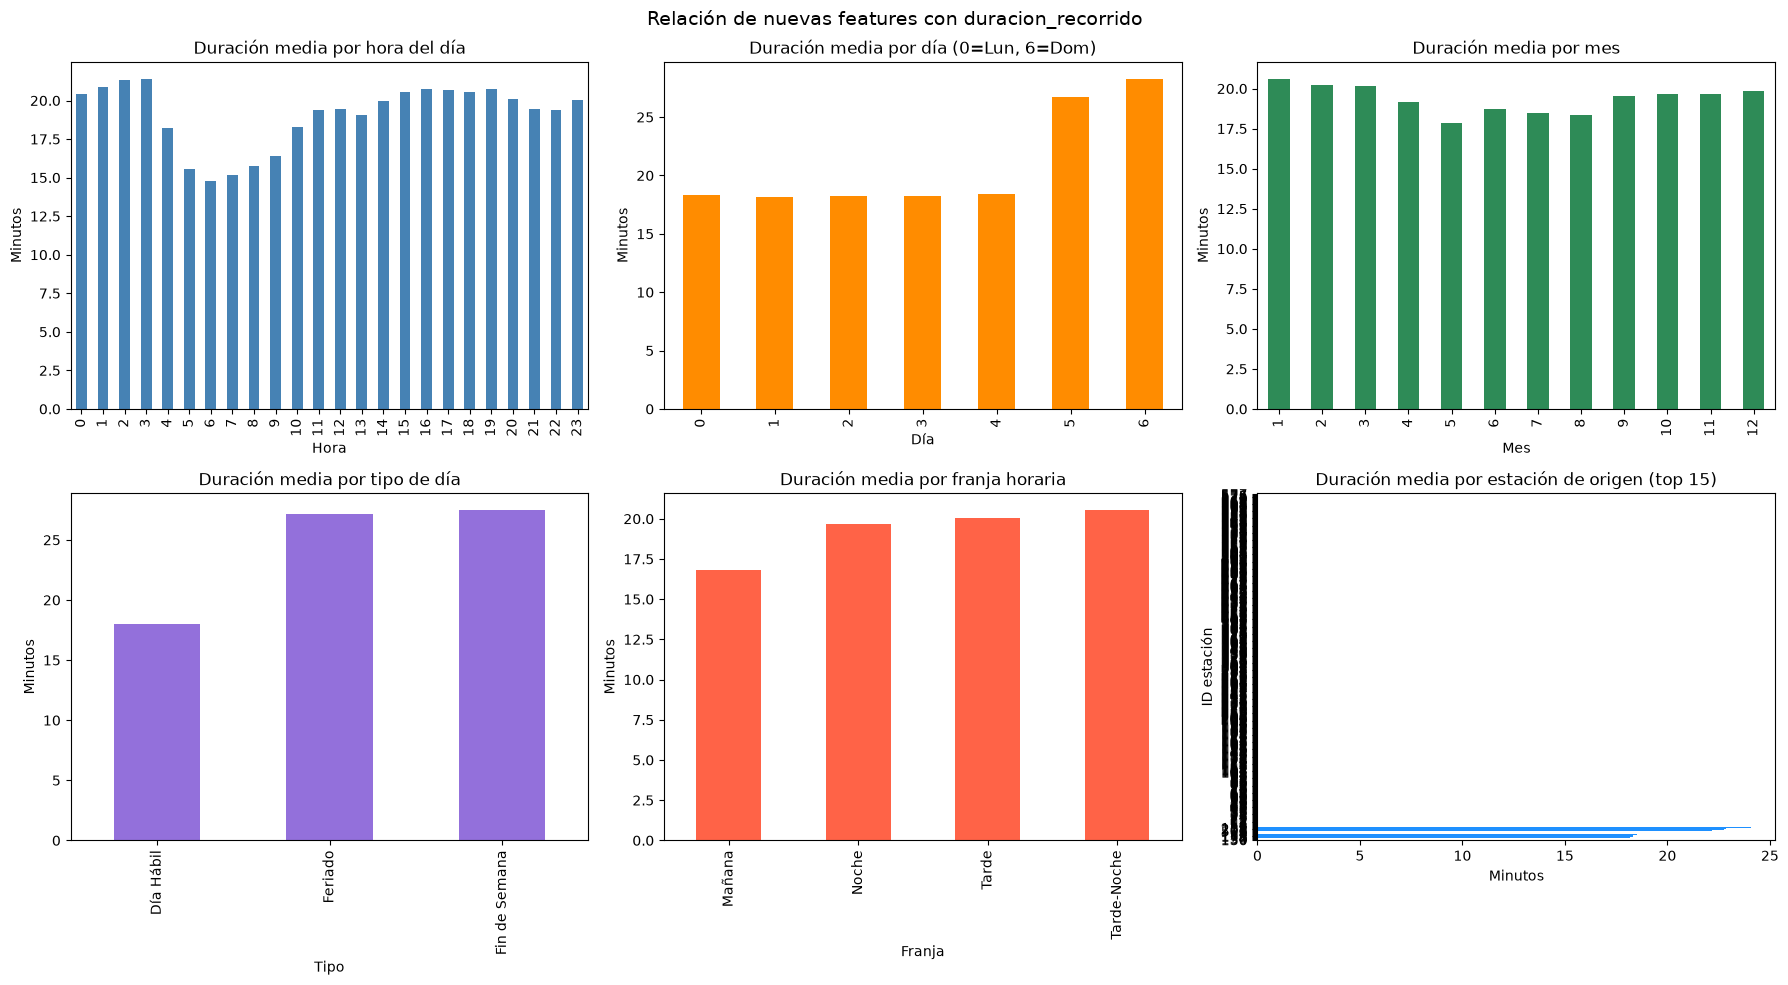

In [51]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Relación de nuevas features con duracion_recorrido', fontsize=14)

# Duración media por hora
df.groupby('hora_origen')['duracion_recorrido'].mean().plot(
    kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Duración media por hora del día')
axes[0, 0].set_xlabel('Hora')
axes[0, 0].set_ylabel('Minutos')

# Duración media por día de la semana
df.groupby('dia_semana')['duracion_recorrido'].mean().plot(
    kind='bar', ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title('Duración media por día (0=Lun, 6=Dom)')
axes[0, 1].set_xlabel('Día')
axes[0, 1].set_ylabel('Minutos')

# Duración media por mes
df.groupby('mes_origen')['duracion_recorrido'].mean().plot(
    kind='bar', ax=axes[0, 2], color='seagreen')
axes[0, 2].set_title('Duración media por mes')
axes[0, 2].set_xlabel('Mes')
axes[0, 2].set_ylabel('Minutos')

# Duración por tipo de día
df.groupby('tipo_dia')['duracion_recorrido'].mean().plot(
    kind='bar', ax=axes[1, 0], color='mediumpurple')
axes[1, 0].set_title('Duración media por tipo de día')
axes[1, 0].set_xlabel('Tipo')
axes[1, 0].set_ylabel('Minutos')

# Duración por franja horaria
df.groupby('franja_horaria')['duracion_recorrido'].mean().plot(
    kind='bar', ax=axes[1, 1], color='tomato')
axes[1, 1].set_title('Duración media por franja horaria')
axes[1, 1].set_xlabel('Franja')
axes[1, 1].set_ylabel('Minutos')

# Duración media por estación de origen (top 15 más frecuentes)
top_estaciones = df['id_estacion_origen'].value_counts().head(15).index
df[df['id_estacion_origen'].isin(top_estaciones)].groupby('id_estacion_origen', observed=True)['duracion_recorrido'].mean().sort_values().plot(
    kind='barh', ax=axes[1, 2], color='dodgerblue')
axes[1, 2].set_title('Duración media por estación de origen (top 15)')
axes[1, 2].set_xlabel('Minutos')
axes[1, 2].set_ylabel('ID estación')

plt.tight_layout()
plt.show()

---
## 3. Encoding de variables categóricas

| Variable | Técnica | Categoría de referencia (all-zeros) |
|---|---|---|
| `genero` | Label Encoding | — (MALE=0 / FEMALE=1 / OTHER=2) |
| `modelo_bicicleta` | Label Encoding | — (FIT=0 / ICONIC=1) |
| `tipo_dia` | One-Hot (`drop_first=True`) | `Día Hábil` (representado por todas las dummies = 0) |
| `franja_horaria` | One-Hot (`drop_first=True`) | `Mañana` (representado por todas las dummies = 0) |

> **Dummy trap:** con `drop_first=False` se incluyen **todas** las categorías como columnas, lo que genera  
> multicolinealidad perfecta (su suma siempre es 1). Usando `drop_first=True` se elimina una categoría  
> que queda implícita cuando todas las demás columnas valen 0.

In [53]:
# ─── Label Encoding: genero ───────────────────────────────────────────────────
le_genero = LabelEncoder()
df['genero_enc'] = le_genero.fit_transform(df['genero'].astype(str))
print('Clases genero:', list(zip(le_genero.classes_, le_genero.transform(le_genero.classes_))))

Clases genero: [('FEMALE', 0), ('MALE', 1), ('OTHER', 2), ('nan', 3)]


In [54]:
# ─── Label Encoding: modelo_bicicleta ────────────────────────────────────────
le_modelo = LabelEncoder()
df['modelo_bicicleta_enc'] = le_modelo.fit_transform(df['modelo_bicicleta'].astype(str))
print('Clases modelo_bicicleta:', list(zip(le_modelo.classes_, le_modelo.transform(le_modelo.classes_))))

Clases modelo_bicicleta: [('FIT', 0), ('ICONIC', 1)]


In [55]:
# ─── One-Hot Encoding: tipo_dia ───────────────────────────────────────────────
# drop_first=True elimina 'Día Hábil' (primera categoría en orden alfabético).
# Un registro con tipo_dia_Feriado=0 y tipo_dia_Fin de Semana=0 implica Día Hábil.
tipo_dia_ohe = pd.get_dummies(df['tipo_dia'], prefix='tipo_dia', drop_first=True)
df = pd.concat([df, tipo_dia_ohe], axis=1)
print('Columnas OHE tipo_dia (referencia: Día Hábil):', list(tipo_dia_ohe.columns))

Columnas OHE tipo_dia (referencia: Día Hábil): ['tipo_dia_Feriado', 'tipo_dia_Fin de Semana']


In [56]:
# ─── One-Hot Encoding: franja_horaria ────────────────────────────────────────
# drop_first=True elimina 'Mañana' (primera categoría en orden alfabético).
# Un registro con todas las dummies = 0 implica franja Mañana.
franja_ohe = pd.get_dummies(df['franja_horaria'], prefix='franja', drop_first=True)
df = pd.concat([df, franja_ohe], axis=1)
print('Columnas OHE franja_horaria (referencia: Mañana):', list(franja_ohe.columns))

Columnas OHE franja_horaria (referencia: Mañana): ['franja_Noche', 'franja_Tarde', 'franja_Tarde-Noche']


In [57]:
# ─── Codificación cíclica: hora y día de la semana ───────────────────────────
# Las features cíclicas (hora, día) tienen un problema con el encoding lineal:
# la hora 23 y la hora 0 deberían estar «cerca», pero numéricamente son extremos.
# La codificación seno/coseno captura esa circularidad.

df['hora_sin'] = np.sin(2 * np.pi * df['hora_origen'] / 24)
df['hora_cos'] = np.cos(2 * np.pi * df['hora_origen'] / 24)

df['dia_sin']  = np.sin(2 * np.pi * df['dia_semana'] / 7)
df['dia_cos']  = np.cos(2 * np.pi * df['dia_semana'] / 7)

df['mes_sin']  = np.sin(2 * np.pi * df['mes_origen'] / 12)
df['mes_cos']  = np.cos(2 * np.pi * df['mes_origen'] / 12)

print('Encoding cíclico hora / día / mes creado.')

Encoding cíclico hora / día / mes creado.


---
## Definición del conjunto de features para el modelo

In [58]:
# ─── Target ───────────────────────────────────────────────────────────────────
TARGET = 'duracion_recorrido'

# ─── Features seleccionadas ───────────────────────────────────────────────────
# Solo se incluyen variables conocidas al INICIO del viaje.
# Se excluyen lat/lon destino, id_estacion_destino y cualquier feature
# derivada del destino (data leakage: el destino se conoce al finalizar).
#
# OHE con drop_first=True:
#   tipo_dia   → referencia: 'Día Hábil'  (Feriado=0, Fin de Semana=0)
#   franja     → referencia: 'Mañana'     (Noche=0, Tarde=0, Tarde-Noche=0)
FEATURES = [
    # Geoespaciales (solo origen, conocido al inicio)
    'long_estacion_origen',
    'lat_estacion_origen',
    # Temporales (numéricas crudas)
    'hora_origen',
    'mes_origen',
    'dia_semana',
    # Temporales (cíclicas)
    'hora_sin', 'hora_cos',
    'dia_sin',  'dia_cos',
    'mes_sin',  'mes_cos',
    # Categóricas binarias
    'es_finde',
    'es_feriado',
    'genero_enc',
    'modelo_bicicleta_enc',
    # OHE tipo_dia (sin 'Día Hábil' → es la referencia)
    'tipo_dia_Feriado',
    'tipo_dia_Fin de Semana',
    # OHE franja_horaria (sin 'Mañana' → es la referencia)
    'franja_Noche',
    'franja_Tarde',
    'franja_Tarde-Noche',
]

# Asegurar tipos numéricos para el modelo
df[FEATURES] = df[FEATURES].astype(float)
df[TARGET]   = df[TARGET].astype(float)

X = df[FEATURES]
y = df[TARGET]

print(f'Features: {len(FEATURES)}')
print(f'Filas (X): {X.shape[0]:,}')
print('\nPrimeras filas de X:')
X.head()

Features: 20
Filas (X): 3,113,895

Primeras filas de X:


,long_estacion_origen,lat_estacion_origen,hora_origen,mes_origen,dia_semana,hora_sin,hora_cos,dia_sin,dia_cos,mes_sin,mes_cos,es_finde,es_feriado,genero_enc,modelo_bicicleta_enc,tipo_dia_Feriado,tipo_dia_Fin de Semana,franja_Noche,franja_Tarde,franja_Tarde-Noche
0,-58.490739,-34.597130,18.0,1.0,1.0,-1.000000,-1.836970e-16,0.781831,0.62349,0.5,0.866025,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-58.511930,-34.607500,22.0,1.0,1.0,-0.500000,8.660254e-01,0.781831,0.62349,0.5,0.866025,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-58.367492,-34.615598,15.0,1.0,1.0,-0.707107,-7.071068e-01,0.781831,0.62349,0.5,0.866025,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,-58.435408,-34.596096,17.0,1.0,1.0,-0.965926,-2.588190e-01,0.781831,0.62349,0.5,0.866025,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0
6,-58.480464,-34.552148,21.0,1.0,1.0,-0.707107,7.071068e-01,0.781831,0.62349,0.5,0.866025,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


## Train / Test Split

In [59]:
# 80% entrenamiento, 20% test. random_state para reproducibilidad.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}  |  y_test: {y_test.shape}')

X_train: (2491116, 20)  |  X_test: (622779, 20)
y_train: (2491116,)  |  y_test: (622779,)


---
##  Escalado / Normalización

Se aplica **StandardScaler** (media 0, desvío 1) — adecuado para la mayoría de los algoritmos de ML supervisado y para PCA.

> **Nota:** el scaler se ajusta **solo con train** (`fit`) y luego se aplica tanto a train como a test (`transform`).  
> Esto evita *data leakage*.

In [60]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convertir de vuelta a DataFrame para mantener nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURES, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=FEATURES, index=X_test.index)

print('Escalado completado.')
print('Media aproximada de columnas en train (debe ser ~0):')
print(X_train_scaled.mean().round(4).head(8))

Escalado completado.
Media aproximada de columnas en train (debe ser ~0):
long_estacion_origen    0.0
lat_estacion_origen     0.0
hora_origen             0.0
mes_origen             -0.0
dia_semana             -0.0
hora_sin               -0.0
hora_cos                0.0
dia_sin                -0.0
dtype: float64


---
## 7. Selección de features – Filtros estadísticos

Se usa `SelectKBest` con `f_regression` (test F de correlación lineal con el target) para rankear las features más informativas.

In [61]:
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_train_scaled, y_train)

scores_df = pd.DataFrame({
    'feature': FEATURES,
    'f_score': selector.scores_,
    'p_value': selector.pvalues_
}).sort_values('f_score', ascending=False)

print('Ranking de features (F-score):')
scores_df

Ranking de features (F-score):


,feature,f_score,p_value
11,es_finde,149451.302584,0.000000e+00
16,tipo_dia_Fin de Semana,145076.177640,0.000000e+00
4,dia_semana,66830.684208,0.000000e+00
7,dia_sin,64572.303573,0.000000e+00
5,hora_sin,34330.581286,0.000000e+00
15,tipo_dia_Feriado,23256.596453,0.000000e+00
12,es_feriado,23256.596453,0.000000e+00
2,hora_origen,13620.028041,0.000000e+00
19,franja_Tarde-Noche,8504.515631,0.000000e+00
13,genero_enc,6955.171907,0.000000e+00


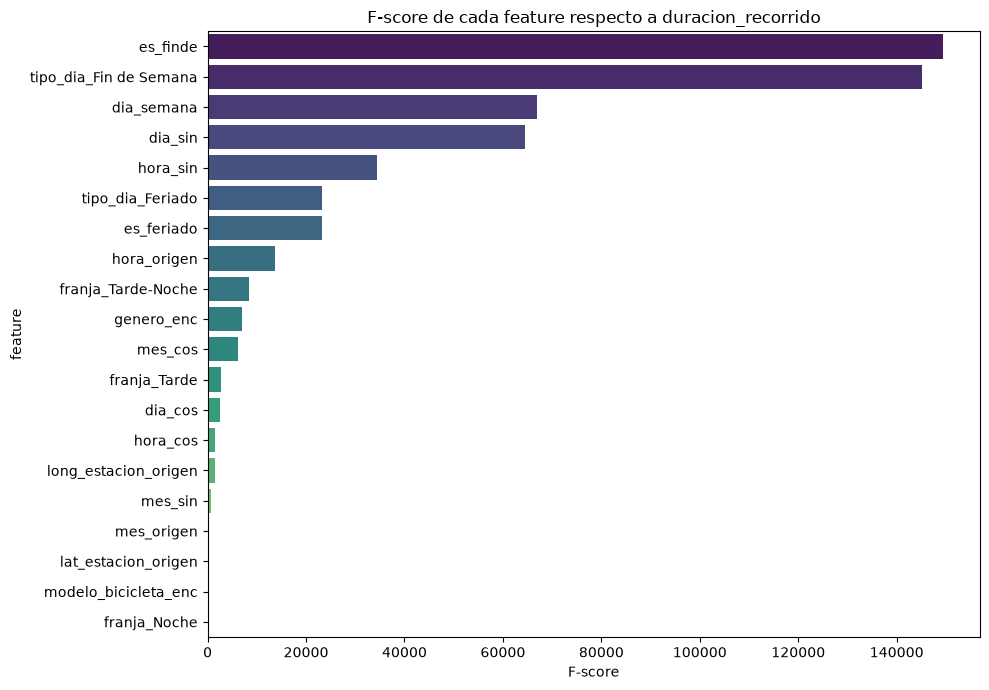

In [62]:
# Visualización del ranking
plt.figure(figsize=(10, 7))
sns.barplot(
    data=scores_df,
    y='feature',
    x='f_score',
    palette='viridis'
)
plt.title('F-score de cada feature respecto a duracion_recorrido')
plt.xlabel('F-score')
plt.tight_layout()
plt.show()

In [63]:
# ─── Selección de las top-K features más relevantes ──────────────────────────
# Se descartan features con p-value >= 0.05 (no significativas)
features_significativas = scores_df[scores_df['p_value'] < 0.05]['feature'].tolist()
print(f'Features significativas (p < 0.05): {len(features_significativas)}')
print(features_significativas)

X_train_sel = X_train_scaled[features_significativas]
X_test_sel  = X_test_scaled[features_significativas]
print(f'\nShape tras selección: train={X_train_sel.shape}, test={X_test_sel.shape}')

Features significativas (p < 0.05): 20
['es_finde', 'tipo_dia_Fin de Semana', 'dia_semana', 'dia_sin', 'hora_sin', 'tipo_dia_Feriado', 'es_feriado', 'hora_origen', 'franja_Tarde-Noche', 'genero_enc', 'mes_cos', 'franja_Tarde', 'dia_cos', 'hora_cos', 'long_estacion_origen', 'mes_sin', 'mes_origen', 'lat_estacion_origen', 'modelo_bicicleta_enc', 'franja_Noche']

Shape tras selección: train=(2491116, 20), test=(622779, 20)


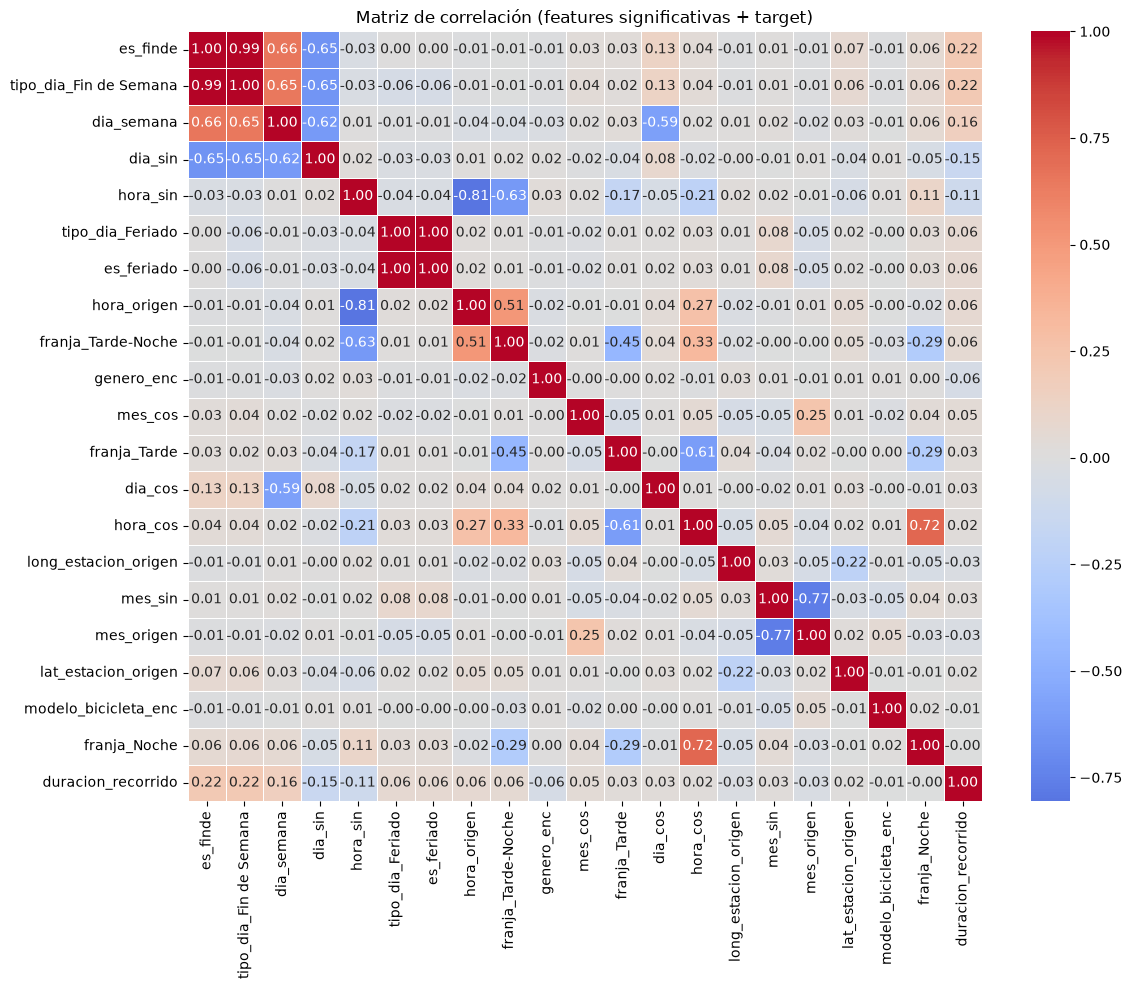

In [64]:
# ─── Mapa de correlación (features seleccionadas + target) ───────────────────
# Tomamos una muestra para el cálculo de correlación
sample_idx = X_train.index[:10000]
corr_df = X_train_sel.loc[sample_idx].copy()
corr_df['duracion_recorrido'] = y_train.loc[sample_idx]

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_df.corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5
)
plt.title('Matriz de correlación (features significativas + target)')
plt.tight_layout()
plt.show()

## Reducción de dimensionalidad – PCA

PCA transforma el espacio de features en componentes no correlacionadas que maximizan la varianza explicada.

### Ventajas
- Elimina multicolinealidad entre features (ej. lat/lon de origen pueden correlacionarse con las features cíclicas de hora).
- Puede acelerar el entrenamiento de modelos sensibles al número de features.

### Desventajas
- Pierde interpretabilidad: las componentes son combinaciones lineales de las features originales.
- La varianza explicada no implica necesariamente mayor poder predictivo.

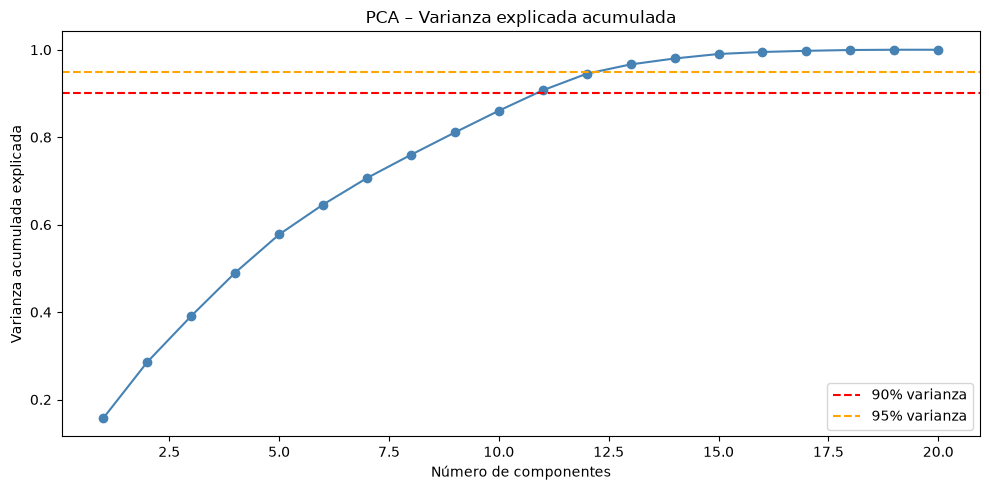

Componentes para el 90% de varianza: 11
Componentes para el 95% de varianza: 13


In [65]:
# ─── PCA sobre las features seleccionadas ────────────────────────────────────
pca = PCA()
pca.fit(X_train_sel)

varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, 'o-', color='steelblue')
plt.axhline(0.90, color='red', linestyle='--', label='90% varianza')
plt.axhline(0.95, color='orange', linestyle='--', label='95% varianza')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada explicada')
plt.title('PCA – Varianza explicada acumulada')
plt.legend()
plt.tight_layout()
plt.show()

# Componentes necesarios para 90% y 95% de varianza
n_90 = np.argmax(varianza_acumulada >= 0.90) + 1
n_95 = np.argmax(varianza_acumulada >= 0.95) + 1
print(f'Componentes para el 90% de varianza: {n_90}')
print(f'Componentes para el 95% de varianza: {n_95}')

In [66]:
# ─── Aplicar PCA con n componentes (95% varianza) ────────────────────────────
n_components = n_95  # Ajustable

pca_final = PCA(n_components=n_components)
X_train_pca = pca_final.fit_transform(X_train_sel)
X_test_pca  = pca_final.transform(X_test_sel)

col_pca = [f'PC{i+1}' for i in range(n_components)]
X_train_pca = pd.DataFrame(X_train_pca, columns=col_pca, index=X_train_sel.index)
X_test_pca  = pd.DataFrame(X_test_pca,  columns=col_pca, index=X_test_sel.index)

print(f'PCA aplicado con {n_components} componentes.')
print(f'Shape PCA train: {X_train_pca.shape}  |  test: {X_test_pca.shape}')
print(f'Varianza explicada total: {pca_final.explained_variance_ratio_.sum():.4f}')

PCA aplicado con 13 componentes.
Shape PCA train: (2491116, 13)  |  test: (622779, 13)
Varianza explicada total: 0.9665


In [67]:
# ─── Resumen varianza por componente ─────────────────────────────────────────
pca_var_df = pd.DataFrame({
    'Componente': col_pca,
    'Varianza explicada': pca_final.explained_variance_ratio_,
    'Varianza acumulada': np.cumsum(pca_final.explained_variance_ratio_)
})
pca_var_df

,Componente,Varianza explicada,Varianza acumulada
0,PC1,0.157560,0.157560
1,PC2,0.128240,0.285801
2,PC3,0.105238,0.391039
3,PC4,0.099095,0.490133
4,PC5,0.087372,0.577506
5,PC6,0.068431,0.645937
6,PC7,0.060662,0.706599
7,PC8,0.053123,0.759723
8,PC9,0.051149,0.810872
9,PC10,0.049682,0.860554


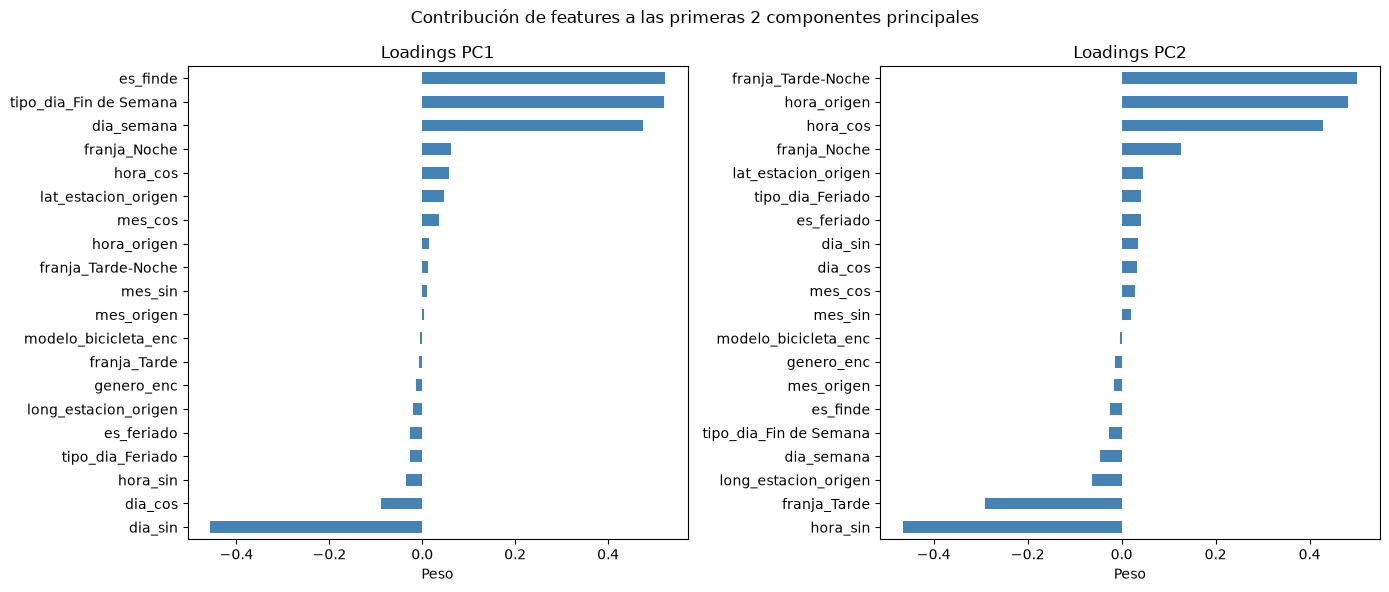

In [68]:
# ─── Loadings: contribución de cada feature original a las primeras 2 PCs ────
loadings = pd.DataFrame(
    pca_final.components_[:2].T,
    index=features_significativas,
    columns=['PC1', 'PC2']
).sort_values('PC1', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, ax in enumerate(axes):
    pc = f'PC{i+1}'
    loadings[pc].sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Loadings {pc}')
    ax.set_xlabel('Peso')
plt.suptitle('Contribución de features a las primeras 2 componentes principales')
plt.tight_layout()
plt.show()

---
## Resumen y datasets listos para modelado

| Dataset | Shape | Descripción |
|---|---|---|
| `X_train` / `X_test` | features originales sin escalar | |
| `X_train_scaled` / `X_test_scaled` | todas las features escaladas | Usar para modelos lineales / SVM |
| `X_train_sel` / `X_test_sel` | features significativas escaladas | Usar cuando se quiere interpretabilidad |
| `X_train_pca` / `X_test_pca` | componentes PCA | Usar para reducción de dimensionalidad |

In [69]:
print('=== RESUMEN FINAL ===')
print(f'Observaciones en train : {len(X_train):,}')
print(f'Observaciones en test  : {len(X_test):,}')
print()
print(f'Features originales    : {len(FEATURES)}')
print(f'Features significativas: {len(features_significativas)}')
print(f'Componentes PCA (95%): {n_components}')
print()
print(f'Target – duracion_recorrido')
print(f'  Media train: {y_train.mean():.2f} min')
print(f'  Desvío estándar train: {y_train.std():.2f} min')
print(f'  Rango: [{y_train.min():.2f}, {y_train.max():.2f}] min')

=== RESUMEN FINAL ===
Observaciones en train : 2,491,116
Observaciones en test  : 622,779

Features originales    : 20
Features significativas: 20
Componentes PCA (95%): 13

Target – duracion_recorrido
  Media train: 19.43 min
  Desvío estándar train: 12.86 min
  Rango: [3.02, 73.98] min
